# Cell 1 — Installations:

In [1]:
# Step 1: Install packages
!pip install amazon-braket-sdk amazon-braket-default-simulator boto3 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 401.4/401.4 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.9/246.9 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.2/153.2 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.5/15.5 MB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 537.8/537.8 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.5/541.5 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.1/196.1 kB 10.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
omegaconf 2.3.1 requi

# Cell 2 — Imports:

In [2]:
import boto3
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from braket.circuits import Circuit
from braket.devices import LocalSimulator
import json
import time
import psutil
from datetime import datetime, timezone
from scipy.stats import chisquare
import os

In [3]:
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.titlesize': 15,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.format': 'png',
    'axes.linewidth': 1.2,
    'grid.linewidth': 0.8,
    'lines.linewidth': 2,
    'lines.markersize': 8,
    'figure.figsize': (8, 5)
})
print("Publication quality settings applied!")

Publication quality settings applied!


# Cell 3 — AWS Credentials:



## Important
AWS credentials are not stored in this notebook.
Set your credentials as environment variables before running:
- AWS_ACCESS_KEY_ID
- AWS_SECRET_ACCESS_KEY

In [ ]:
# AWS Credentials
AWS_ACCESS_KEY = os.environ.get('AWS_ACCESS_KEY_ID', 'your-AWS_ACCESS_KEY')
AWS_SECRET_KEY = os.environ.get('AWS_SECRET_ACCESS_KEY', 'your-AWS_SECRET_KEY')
AWS_REGION = 'us-east-1'
# Test connection
sts = boto3.client(
    'sts',
    aws_access_key_id=AWS_ACCESS_KEY,
    aws_secret_access_key=AWS_SECRET_KEY,
    region_name=AWS_REGION
)
print(sts.get_caller_identity())

## Benchmark 4: BB84 Quantum Key Distribution

### Overview
This benchmark compares the BB84 quantum key distribution protocol against
classical Diffie-Hellman key exchange.

**Quantum approach:** BB84 uses quantum mechanics to establish a secure shared
secret key. Any eavesdropping attempt disturbs the quantum states and is
detectable through an elevated Quantum Bit Error Rate (QBER).

**Classical approach:** Diffie-Hellman (implemented by Kanishka) establishes
shared secrets over public channels using computational hardness assumptions
based on the discrete logarithm problem.

**Agreed protocol with Classical Lead (Kanishka):**
- Qubits transmitted: 1,000 / 2,000 / 4,000 / 8,000
- Expected sifted key: ~500 / 1,000 / 2,000 / 4,000 bits (~50% after sifting)
- Trials: 10 per configuration
- QBER threshold: 11% (Shor and Preskill 2000, Physical Review Letters)
- Eavesdropping scenarios: 0%, 25%, 50%, 100% intercept rate
- Metrics: QBER, key generation rate, sifted key length, runtime

**Literature support:**
- Bennett and Brassard (1984) — original BB84 protocol
- Shor and Preskill (2000, Physical Review Letters) — security proof,
  QBER threshold of 11% under one-way classical communication
- Escanez-Exposito et al. (2024, Future Internet) — BB84 simulation
  under depolarizing noise and intercept-resend attacks
- Zhu et al. (2026, arXiv:2603.27278) — QBER approaches 25% under
  full intercept-resend attack

**Key question:** Does BB84 provide information-theoretic security advantages
over classical Diffie-Hellman, and how does QBER scale with eavesdropping
intensity?

In [5]:
# Agreed protocol with Classical Lead (Kanishka)
QUBIT_COUNTS = [1000, 2000, 4000, 8000]
TRIALS = 10
QBER_THRESHOLD = 0.11  # Shor-Preskill 2000
EAVESDROP_RATES = [0.0, 0.25, 0.50, 1.0]

print("BB84 QKD Benchmark Configuration")
print("=" * 45)
print(f"Qubits transmitted: {QUBIT_COUNTS}")
print(f"Expected sifted key: ~{[q//2 for q in QUBIT_COUNTS]} bits")
print(f"Trials: {TRIALS}")
print(f"QBER threshold: {QBER_THRESHOLD*100}%")
print(f"Eavesdropping rates: {[f'{r*100:.0f}%' for r in EAVESDROP_RATES]}")
print("=" * 45)

BB84 QKD Benchmark Configuration
Qubits transmitted: [1000, 2000, 4000, 8000]
Expected sifted key: ~[500, 1000, 2000, 4000] bits
Trials: 10
QBER threshold: 11.0%
Eavesdropping rates: ['0%', '25%', '50%', '100%']


### BB84 Protocol Implementation

In [6]:
def run_bb84(n_qubits, eavesdrop_rate=0.0):
    """
    Simulate BB84 QKD protocol.
    Eavesdropping: intercept-resend attack.
    Reference: Bennett and Brassard (1984)
    QBER under full intercept-resend = ~25% (Zhu et al. 2026)
    """
    device = LocalSimulator()
    start = time.time()

    # Step 1: Alice random bits and bases
    alice_bits  = np.random.randint(0, 2, n_qubits)
    alice_bases = np.random.randint(0, 2, n_qubits)  # 0=Z, 1=X

    # Step 2: Bob random bases
    bob_bases = np.random.randint(0, 2, n_qubits)

    bob_results = np.zeros(n_qubits, dtype=int)

    for i in range(n_qubits):
        bit   = int(alice_bits[i])
        basis = int(alice_bases[i])

        # Eve intercepts with probability eavesdrop_rate
        if np.random.random() < eavesdrop_rate:
            eve_basis = np.random.randint(0, 2)
            if eve_basis == basis:
                eve_bit = bit
            else:
                eve_bit = np.random.randint(0, 2)
            bit   = eve_bit
            basis = eve_basis

        # Build circuit — always start with I gate to avoid empty circuit
        circuit = Circuit()
        circuit.i(0)  # Identity gate — ensures circuit is never empty

        if bit == 1:
            circuit.x(0)
        if basis == 1:
            circuit.h(0)
        if bob_bases[i] == 1:
            circuit.h(0)

        result = device.run(circuit, shots=1).result()
        bob_results[i] = int(list(result.measurement_counts.keys())[0])

    runtime = time.time() - start

    # Sifting
    matching = alice_bases == bob_bases
    sifted_alice = alice_bits[matching]
    sifted_bob   = bob_results[matching]
    sifted_key_length = len(sifted_alice)

    # QBER
    qber = float(np.sum(sifted_alice != sifted_bob) / sifted_key_length) \
           if sifted_key_length > 0 else 0.0

    # Key generation rate
    key_gen_rate = sifted_key_length / n_qubits

    return {
        'n_qubits': n_qubits,
        'sifted_key_length': sifted_key_length,
        'qber': round(qber, 4),
        'key_gen_rate': round(key_gen_rate, 4),
        'runtime_seconds': round(runtime, 4),
        'secure': qber < QBER_THRESHOLD
    }

# Test
print("Testing BB84 protocol...")
print("\nNo eavesdropping:")
r = run_bb84(100, eavesdrop_rate=0.0)
print(f"QBER: {r['qber']:.4f} | Sifted key: {r['sifted_key_length']} | Secure: {r['secure']}")

print("\nFull eavesdropping (100%):")
r = run_bb84(100, eavesdrop_rate=1.0)
print(f"QBER: {r['qber']:.4f} | Sifted key: {r['sifted_key_length']} | Secure: {r['secure']}")

Testing BB84 protocol...

No eavesdropping:
QBER: 0.0000 | Sifted key: 48 | Secure: True

Full eavesdropping (100%):
QBER: 0.2333 | Sifted key: 60 | Secure: False


In [7]:
# ── Secure Key Rate (Shor-Preskill 2000) ─────────────────
def binary_entropy(p):
    """
    Binary entropy function H(p) = -p*log2(p) - (1-p)*log2(1-p)
    Used in Shor-Preskill secure key rate formula.
    Reference: Shor and Preskill (2000, Physical Review Letters)
    """
    if p <= 0 or p >= 1:
        return 0
    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)

def secure_key_rate(qber):
    """
    Asymptotic secure key rate per sifted bit.
    R = 1 - 2*H(QBER) (Shor-Preskill 2000)
    R > 0 only when QBER < 11%
    Reference: Shor and Preskill (2000, Physical Review Letters,
    DOI: 10.1103/PhysRevLett.85.441)
    """
    r = 1 - 2 * binary_entropy(qber)
    return max(0, r)  # Rate can't be negative

# Test
print("Secure key rate at different QBER values:")
for qber in [0.0, 0.05, 0.11, 0.15, 0.25]:
    r = secure_key_rate(qber)
    print(f"  QBER={qber:.2f} → R={r:.4f}")

Secure key rate at different QBER values:
  QBER=0.00 → R=1.0000
  QBER=0.05 → R=0.4272
  QBER=0.11 → R=0.0002
  QBER=0.15 → R=0.0000
  QBER=0.25 → R=0.0000


### Full Benchmark: All Qubit Counts and Eavesdropping Scenarios

In [8]:
# ── Full BB84 Benchmark ───────────────────────────────────
def run_bb84_benchmark(qubit_counts, eavesdrop_rates, trials=10):
    """
    Run BB84 benchmark across all qubit counts and eavesdropping rates.
    Includes Shor-Preskill secure key rate calculation.
    Reference: Shor and Preskill (2000, Physical Review Letters)
    """
    all_results = []

    print(f"{'Qubits':>8} | {'Eve%':>5} | {'Trial':>5} | {'QBER':>8} | {'Sifted':>8} | {'KGR':>6} | {'SecureR':>8} | {'Secure':>6} | {'Time(s)':>8}")
    print("-" * 85)

    for n_qubits in qubit_counts:
        for eve_rate in eavesdrop_rates:
            trial_results = []

            for trial in range(1, trials + 1):
                result = run_bb84(n_qubits, eavesdrop_rate=eve_rate)

                # Add secure key rate
                skr = secure_key_rate(result['qber'])
                result['secure_key_rate'] = round(skr, 4)
                result['secure_key_bits'] = int(result['sifted_key_length'] * skr)

                trial_results.append(result)

                print(f"{n_qubits:>8,} | {eve_rate*100:>5.0f}% | {trial:>5} | "
                      f"{result['qber']:>8.4f} | {result['sifted_key_length']:>8} | "
                      f"{result['key_gen_rate']:>6.4f} | {skr:>8.4f} | "
                      f"{str(result['secure']):>6} | "
                      f"{result['runtime_seconds']:>8.4f}")

            mean_qber = np.mean([r['qber'] for r in trial_results])
            std_qber = np.std([r['qber'] for r in trial_results])
            mean_sifted = np.mean([r['sifted_key_length'] for r in trial_results])
            mean_kgr = np.mean([r['key_gen_rate'] for r in trial_results])
            mean_skr = np.mean([r['secure_key_rate'] for r in trial_results])
            mean_skb = np.mean([r['secure_key_bits'] for r in trial_results])
            mean_rt = np.mean([r['runtime_seconds'] for r in trial_results])
            secure_count = sum(1 for r in trial_results if r['secure'])

            all_results.append({
                'n_qubits': n_qubits,
                'eavesdrop_rate': eve_rate,
                'trials': trials,
                'mean_qber': round(mean_qber, 4),
                'std_qber': round(std_qber, 4),
                'mean_sifted_key': round(mean_sifted, 1),
                'mean_key_gen_rate': round(mean_kgr, 4),
                'mean_secure_key_rate': round(mean_skr, 4),
                'mean_secure_key_bits': round(mean_skb, 1),
                'mean_runtime_seconds': round(mean_rt, 4),
                'secure_trials': f"{secure_count}/{trials}"
            })

            print(f"\nSummary {n_qubits:,} qubits, Eve={eve_rate*100:.0f}%: "
                  f"Mean QBER={mean_qber:.4f} | Mean SKR={mean_skr:.4f} | "
                  f"Secure keys={mean_skb:.0f} bits | "
                  f"Secure={secure_count}/{trials}\n")
            print("-" * 85)

    return all_results

bb84_results = run_bb84_benchmark(QUBIT_COUNTS, EAVESDROP_RATES, trials=TRIALS)

  Qubits |  Eve% | Trial |     QBER |   Sifted |    KGR |  SecureR | Secure |  Time(s)
-------------------------------------------------------------------------------------
   1,000 |     0% |     1 |   0.0000 |      516 | 0.5160 |   1.0000 |   True |  11.8858
   1,000 |     0% |     2 |   0.0000 |      516 | 0.5160 |   1.0000 |   True |   7.6461
   1,000 |     0% |     3 |   0.0000 |      471 | 0.4710 |   1.0000 |   True |   6.4089
   1,000 |     0% |     4 |   0.0000 |      506 | 0.5060 |   1.0000 |   True |   7.3211
   1,000 |     0% |     5 |   0.0000 |      493 | 0.4930 |   1.0000 |   True |   6.8419
   1,000 |     0% |     6 |   0.0000 |      482 | 0.4820 |   1.0000 |   True |   7.0963
   1,000 |     0% |     7 |   0.0000 |      478 | 0.4780 |   1.0000 |   True |   7.1136
   1,000 |     0% |     8 |   0.0000 |      482 | 0.4820 |   1.0000 |   True |   6.9368
   1,000 |     0% |     9 |   0.0000 |      531 | 0.5310 |   1.0000 |   True |   7.3961
   1,000 |     0% |    10 |   0.000

In [9]:
# ── Experiment Log 001: BB84 Benchmark (Updated) ─────────
experiment_log_bb84_001 = {
    "experiment_id": "qi26_26_BB84_001",
    "benchmark_type": "BB84_QKD",
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "simulator": "LocalSimulator",
    "protocol": {
        "qubit_counts": [1000, 2000, 4000, 8000],
        "eavesdrop_rates": [0.0, 0.25, 0.50, 1.0],
        "trials": 10,
        "qber_threshold": 0.11,
        "attack_type": "intercept-resend",
        "secure_key_rate_formula": "R = 1 - 2H(QBER) (Shor-Preskill 2000)",
        "references": [
            "Bennett and Brassard 1984",
            "Shor and Preskill 2000 (Physical Review Letters)",
            "Rath, Panth, Bhaskar 2026 (arXiv:2603.27278)"
        ]
    },
    "metrics": {
        "results": bb84_results
    },
    "environment": {
        "braket_sdk_version": "1.121.0",
        "python_version": "3.12",
        "region": "us-east-1"
    },
    "notes": "Updated with Shor-Preskill secure key rate R = 1 - 2H(QBER). SKR=1.0 at Eve=0%, SKR drops significantly at Eve=25% (~0.15-0.43), SKR=0.0 at Eve>=50%. Secure key bits reduce dramatically under eavesdropping. Results match theoretical predictions."
}

with open('bb84_experiment_001.json', 'w') as f:
    json.dump(experiment_log_bb84_001, f, indent=2)

print("Experiment 001 updated!")

Experiment 001 updated!


### BB84 Results Visualization

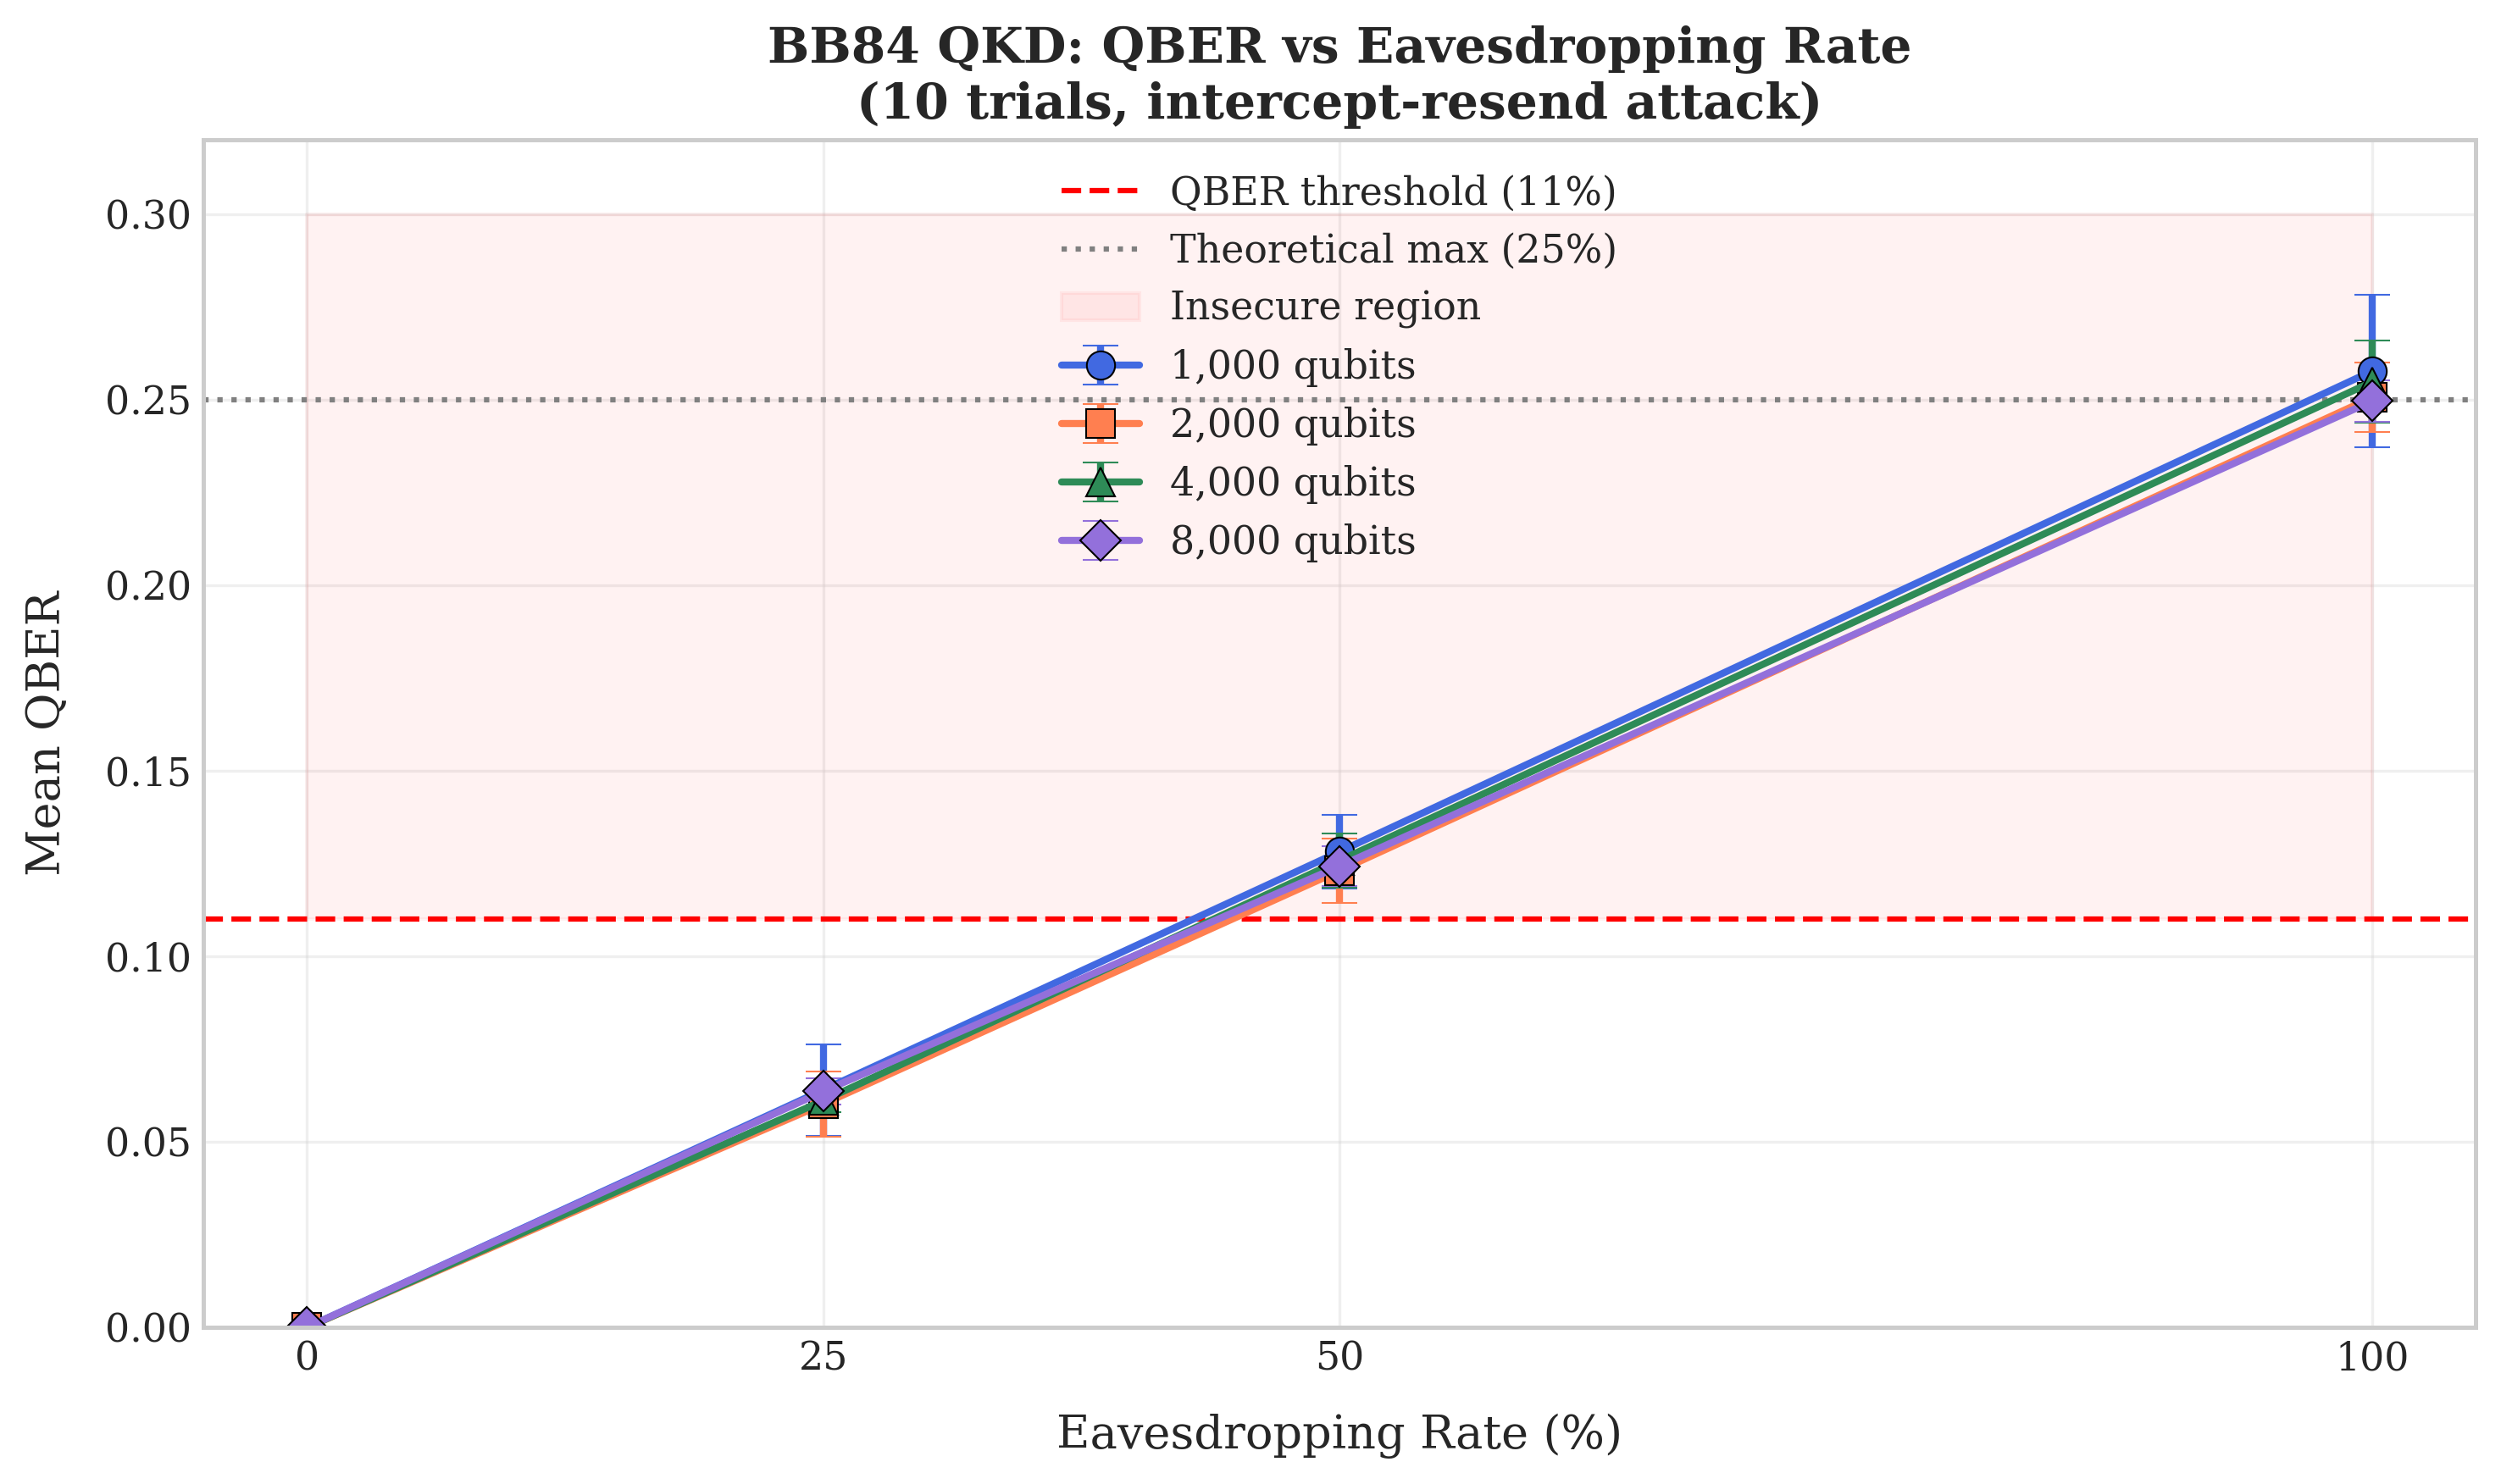

QBER plot saved!


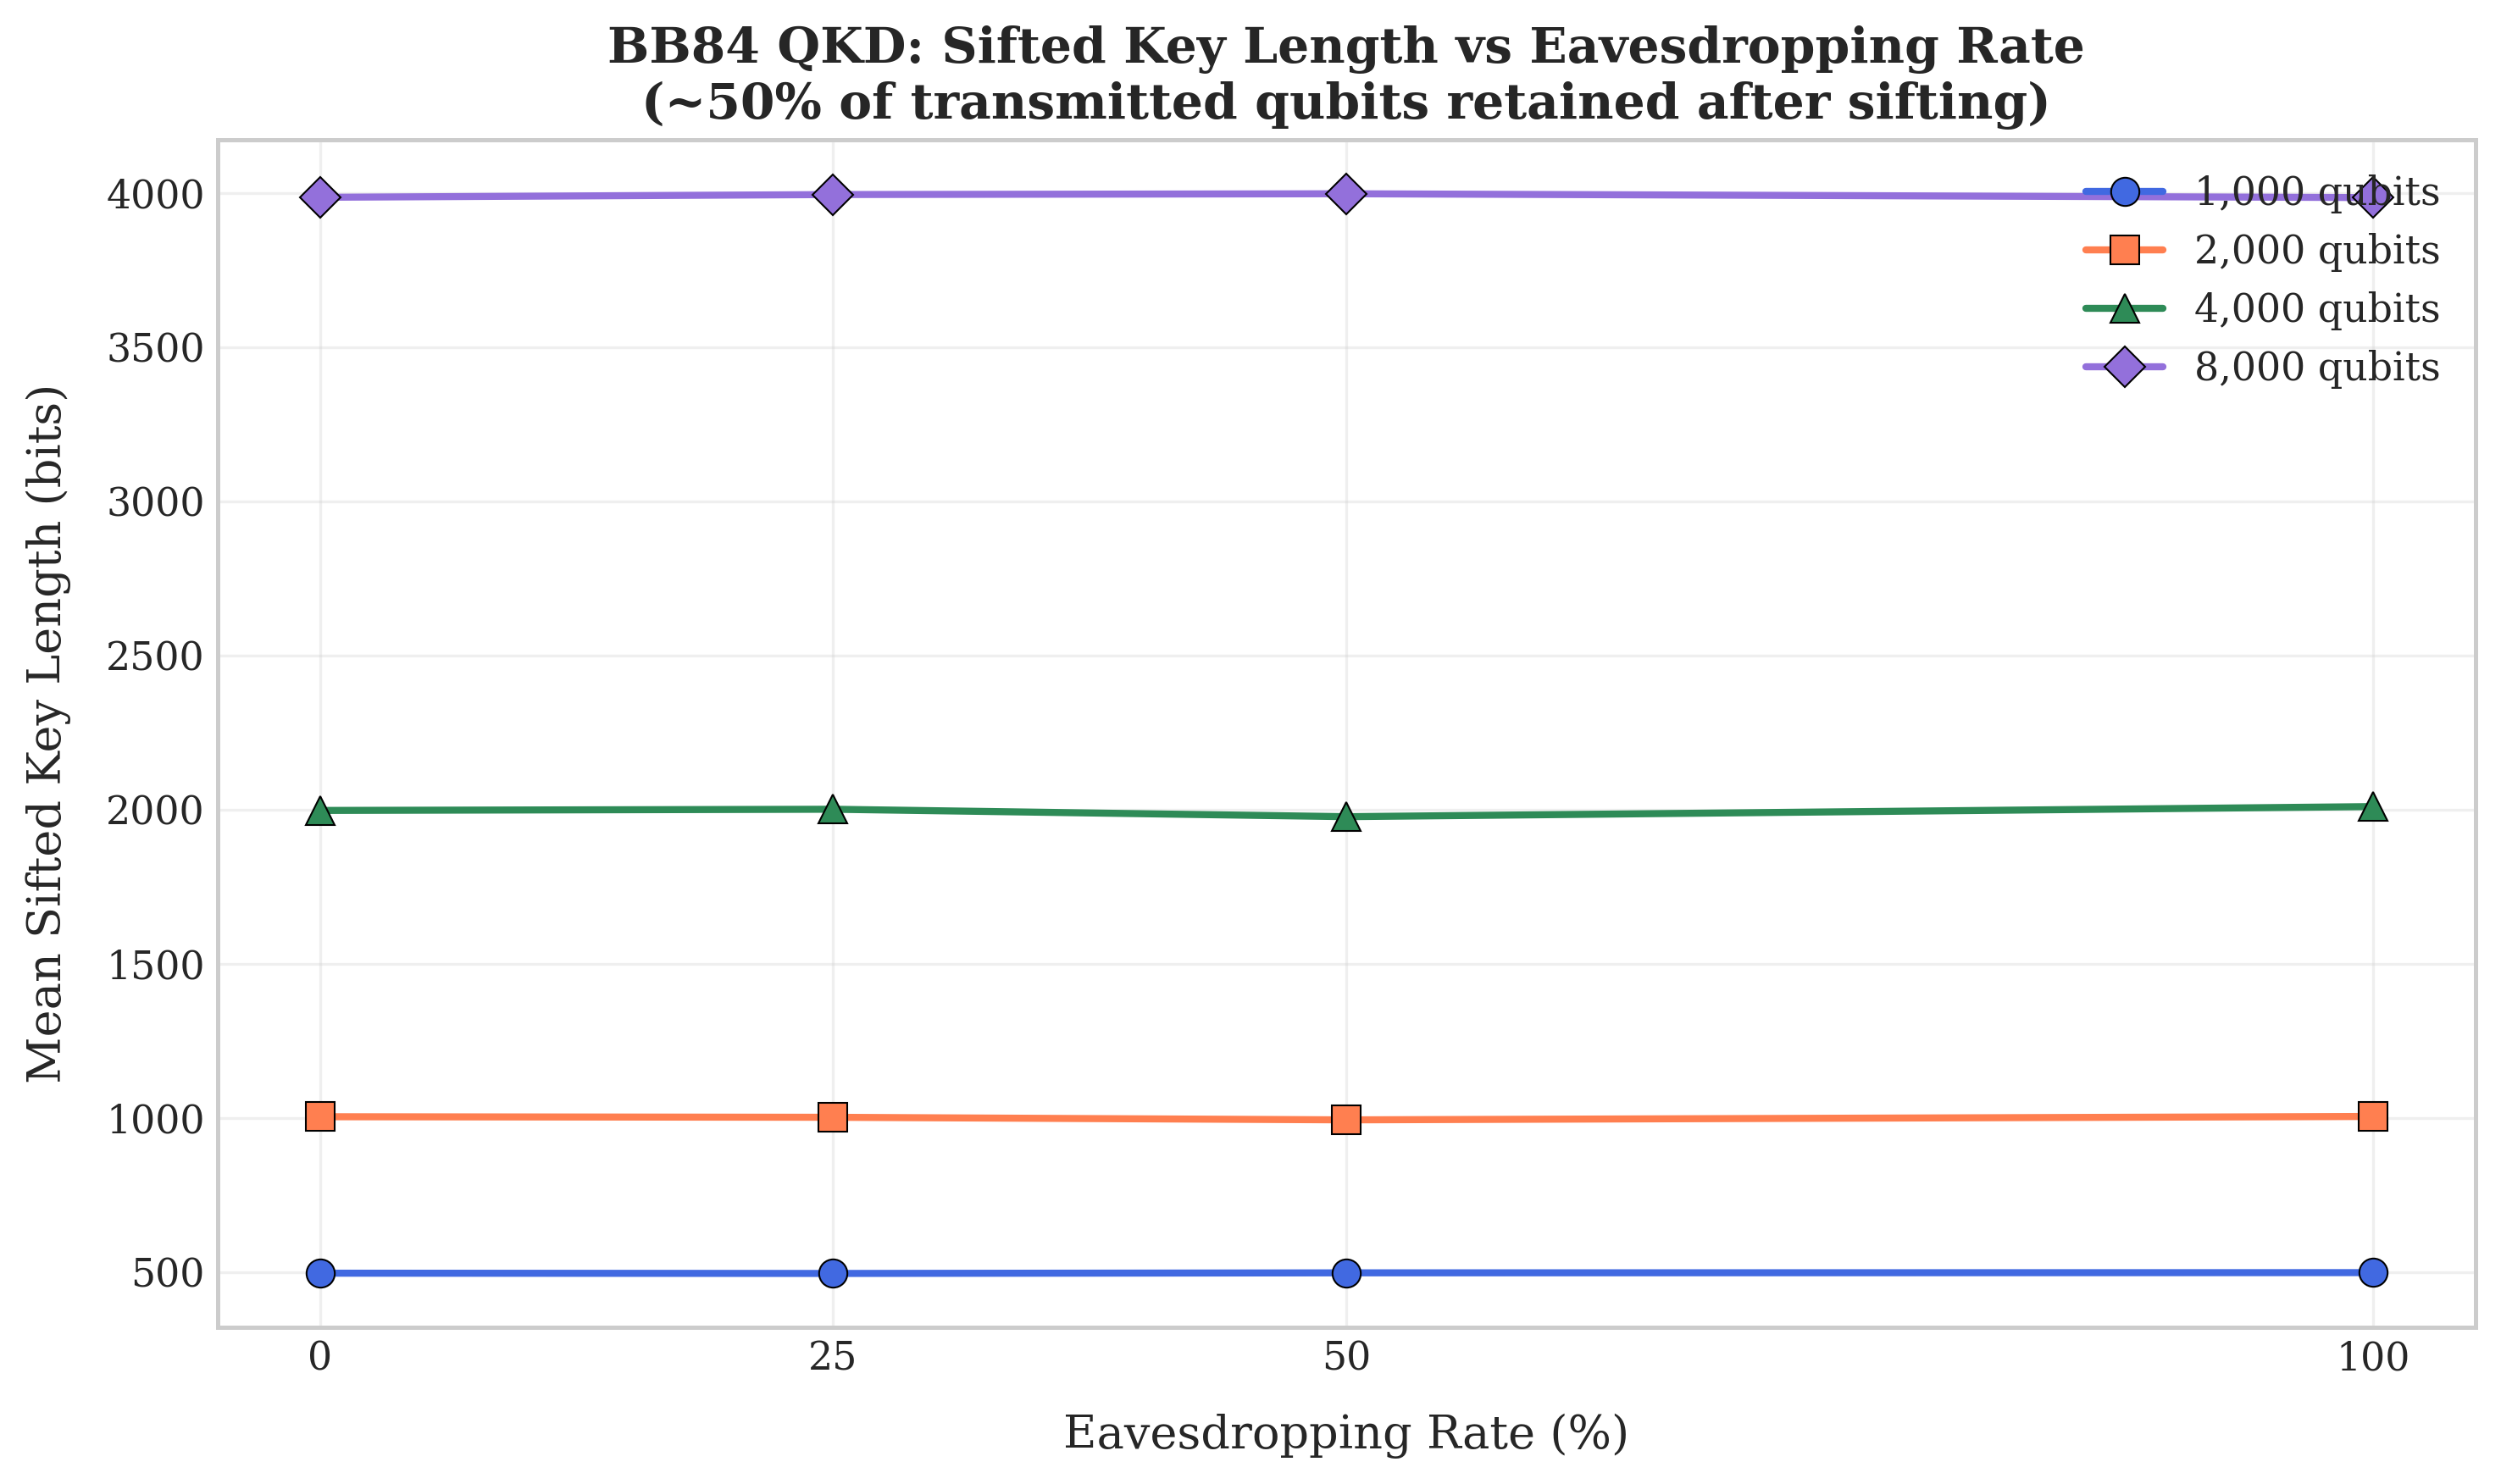

Sifted key plot saved!


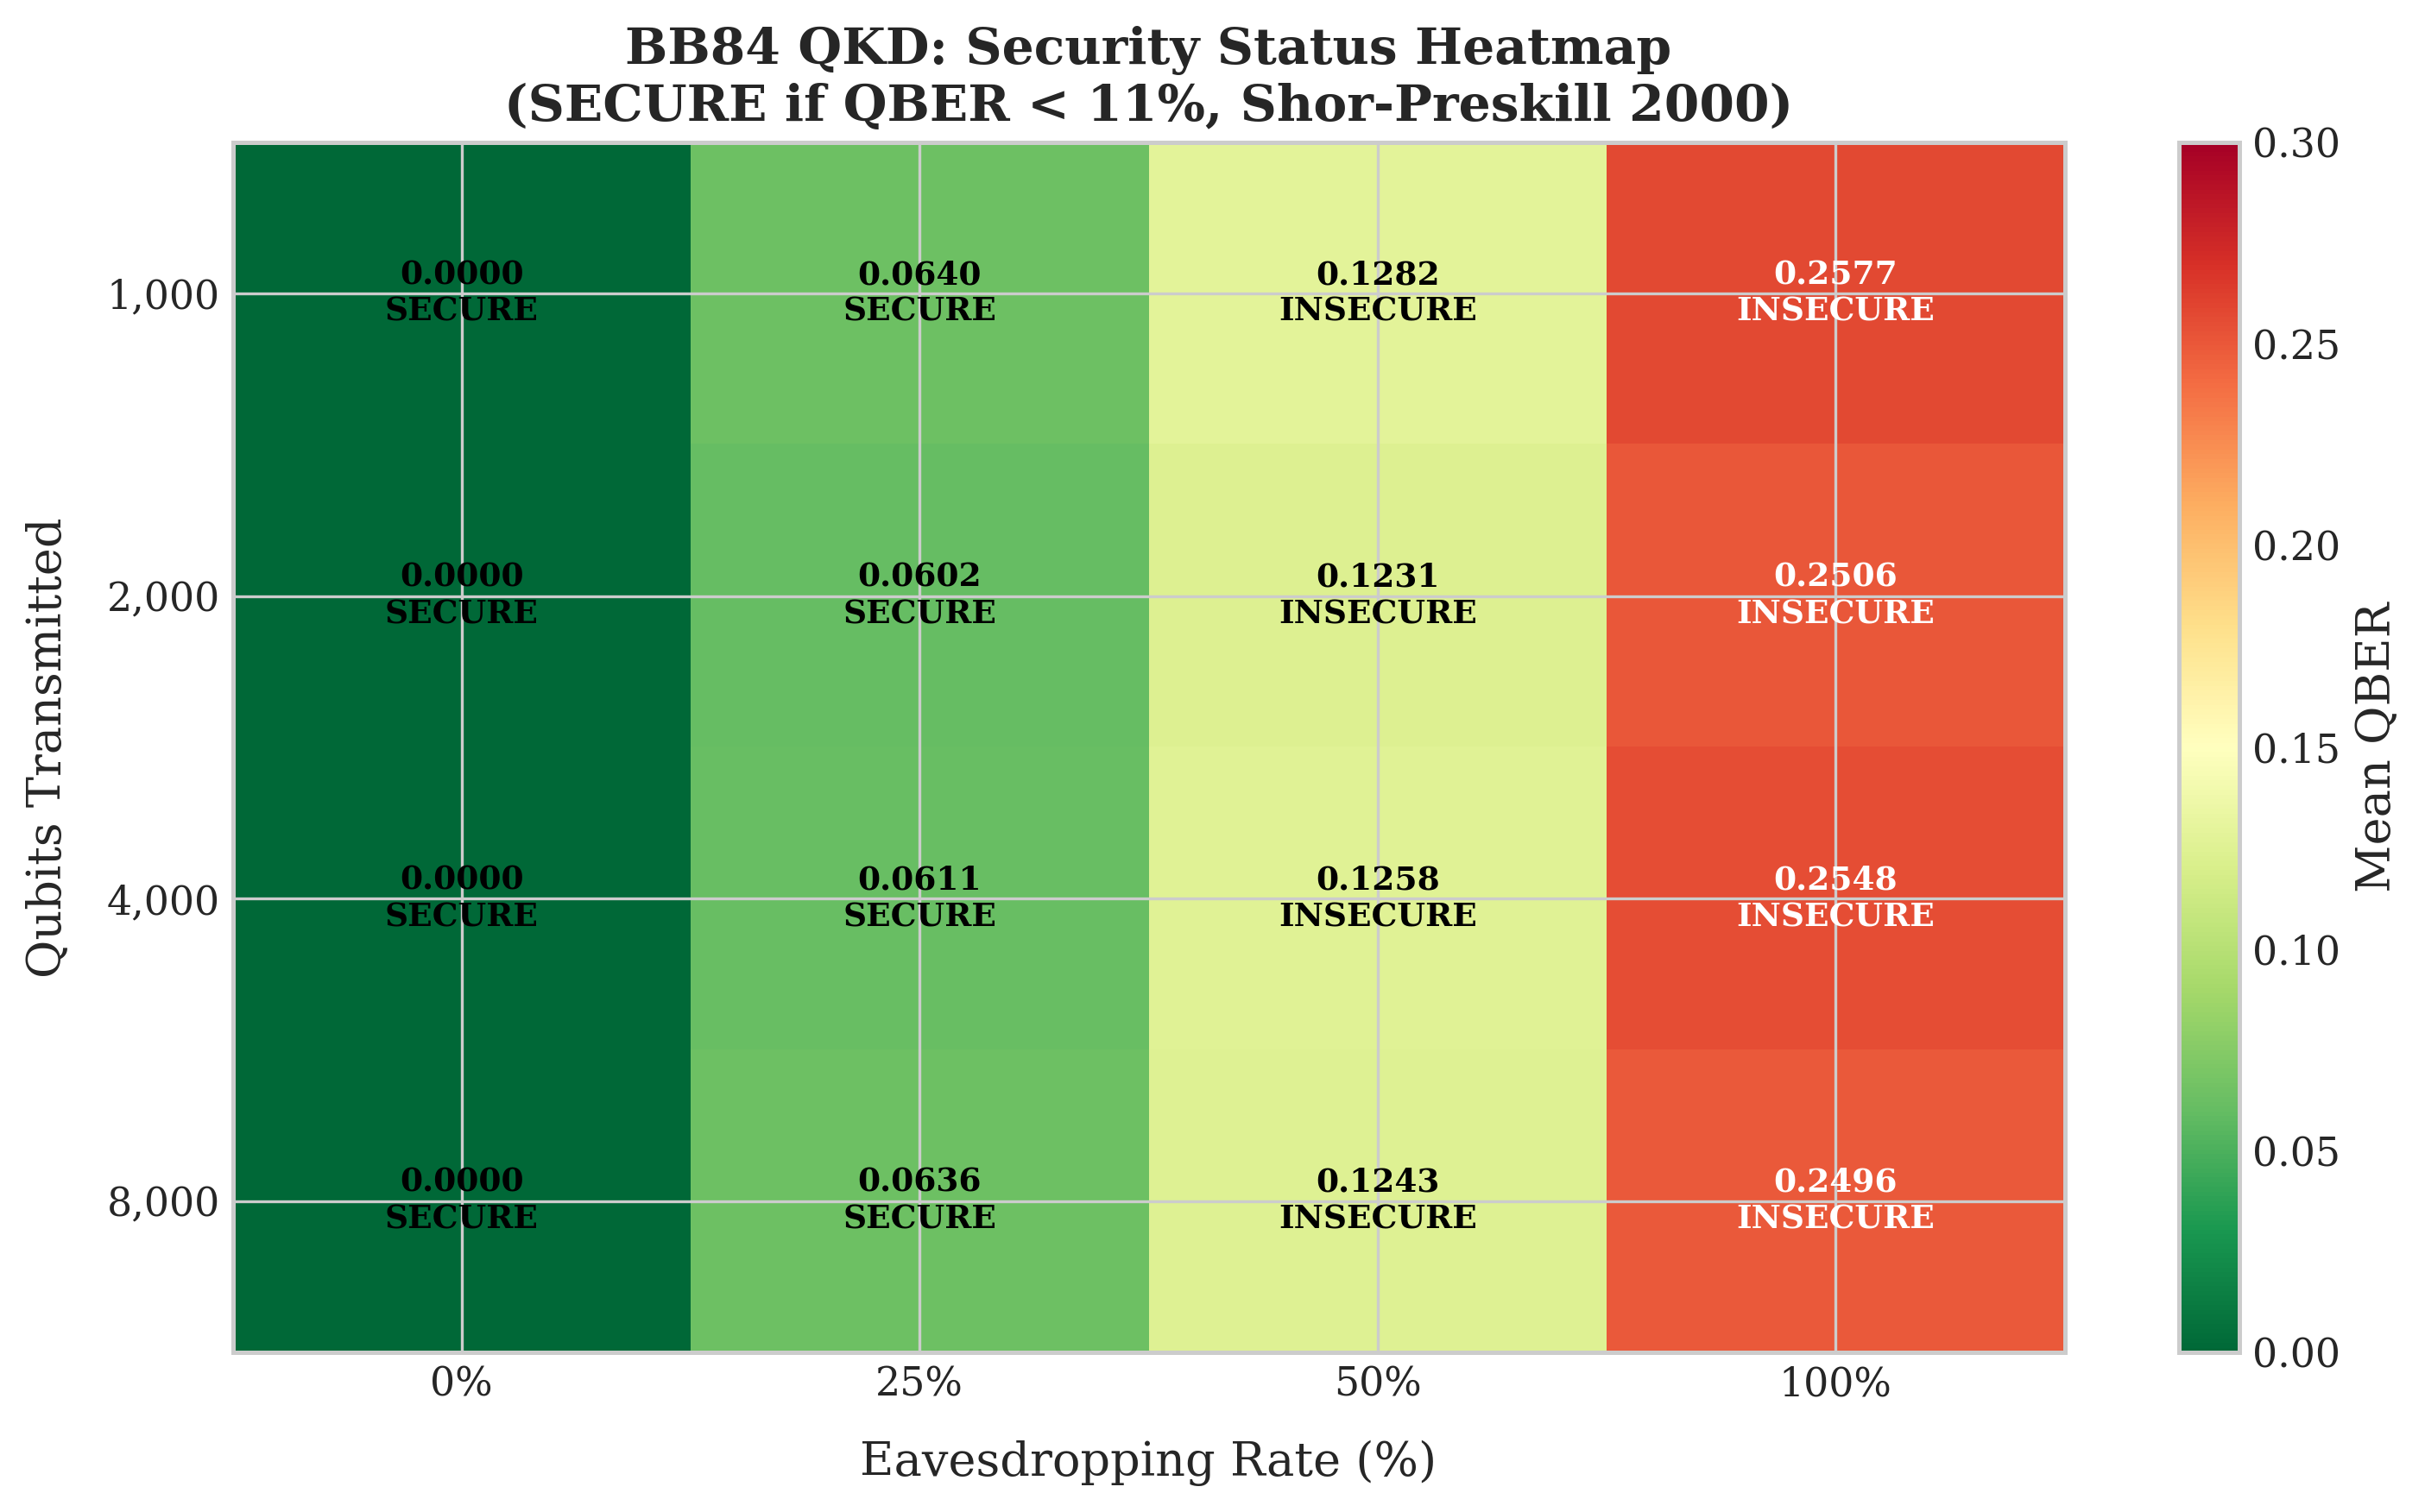

Security heatmap saved!


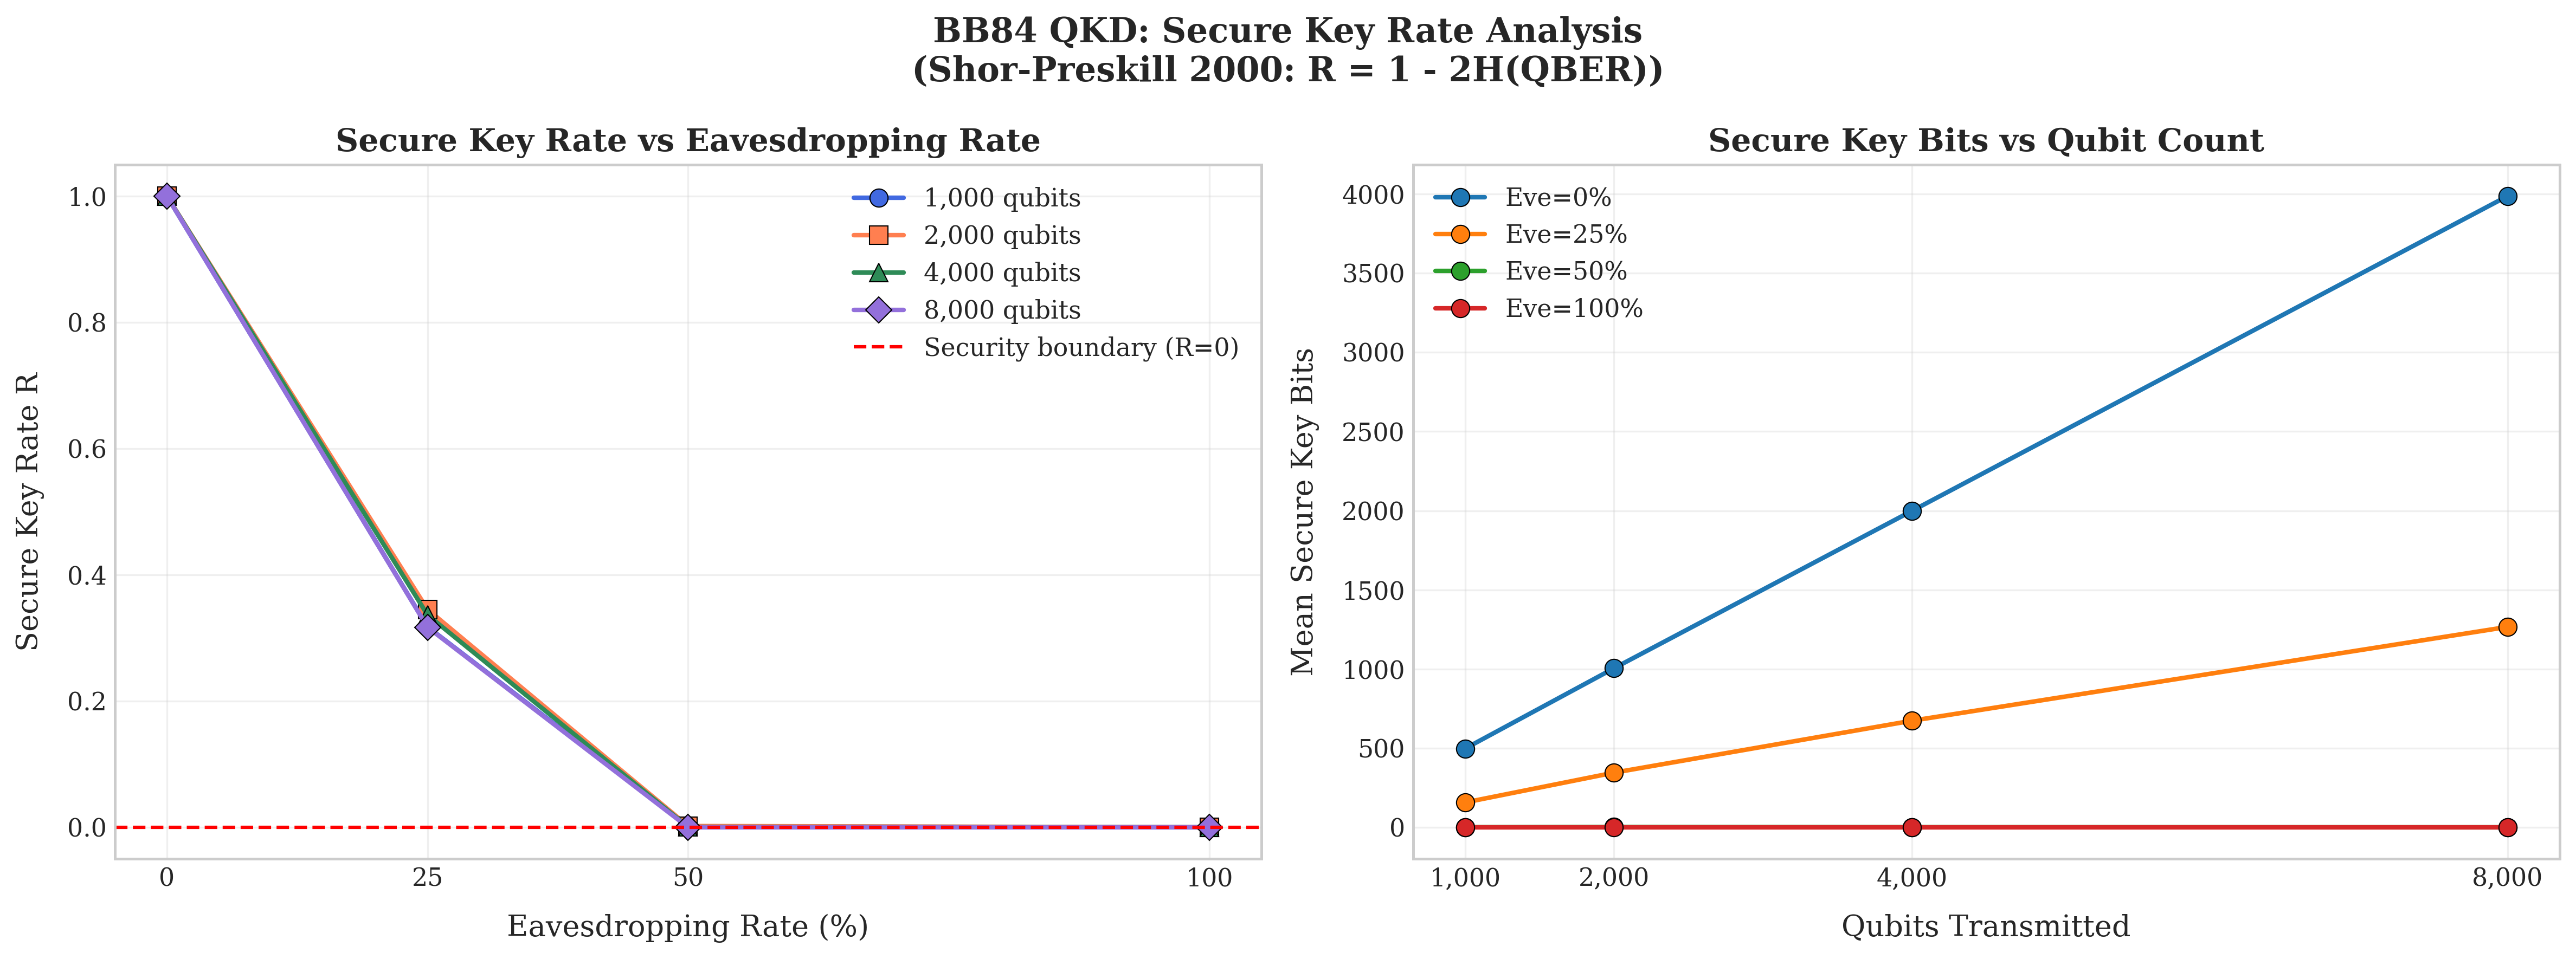

Secure key rate plot saved!


In [11]:
# ── Updated Visualizations with Secure Key Rate ───────────

# ── Plot 1: QBER vs Eavesdropping ────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
for n_qubits in QUBIT_COUNTS:
    q_results = [r for r in bb84_results if r['n_qubits'] == n_qubits]
    eve_rates = [r['eavesdrop_rate'] * 100 for r in q_results]
    mean_qbers = [r['mean_qber'] for r in q_results]
    std_qbers = [r['std_qber'] for r in q_results]
    ax.errorbar(eve_rates, mean_qbers, yerr=std_qbers,
                fmt=f'{markers_q[n_qubits]}-',
                color=colors_q[n_qubits],
                linewidth=2, markersize=8, capsize=5,
                markeredgecolor='black', markeredgewidth=0.5,
                label=f'{n_qubits:,} qubits')
ax.axhline(y=0.11, color='red', linestyle='--',
           linewidth=1.5, label='QBER threshold (11%)')
ax.axhline(y=0.25, color='gray', linestyle=':',
           linewidth=1.5, label='Theoretical max (25%)')
ax.fill_between([0, 100], 0.11, 0.30,
                alpha=0.05, color='red', label='Insecure region')
ax.set_xlabel('Eavesdropping Rate (%)', labelpad=10)
ax.set_ylabel('Mean QBER', labelpad=10)
ax.set_title('BB84 QKD: QBER vs Eavesdropping Rate\n'
             '(10 trials, intercept-resend attack)',
             fontweight='bold')
ax.set_xticks([r*100 for r in EAVESDROP_RATES])
ax.set_ylim(0, 0.32)
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bb84_qber_vs_eavesdrop.png', dpi=300, bbox_inches='tight')
plt.show()
print("QBER plot saved!")

# ── Plot 2: Sifted Key Length ─────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
for n_qubits in QUBIT_COUNTS:
    q_results = [r for r in bb84_results if r['n_qubits'] == n_qubits]
    eve_rates = [r['eavesdrop_rate'] * 100 for r in q_results]
    mean_sifted = [r['mean_sifted_key'] for r in q_results]
    ax.plot(eve_rates, mean_sifted,
            f'{markers_q[n_qubits]}-',
            color=colors_q[n_qubits],
            linewidth=2, markersize=8,
            markeredgecolor='black', markeredgewidth=0.5,
            label=f'{n_qubits:,} qubits')
ax.set_xlabel('Eavesdropping Rate (%)', labelpad=10)
ax.set_ylabel('Mean Sifted Key Length (bits)', labelpad=10)
ax.set_title('BB84 QKD: Sifted Key Length vs Eavesdropping Rate\n'
             '(~50% of transmitted qubits retained after sifting)',
             fontweight='bold')
ax.set_xticks([r*100 for r in EAVESDROP_RATES])
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bb84_sifted_key.png', dpi=300, bbox_inches='tight')
plt.show()
print("Sifted key plot saved!")

# ── Plot 3: Security Heatmap ──────────────────────────────
qber_matrix = np.zeros((len(QUBIT_COUNTS), len(EAVESDROP_RATES)))
for i, n_qubits in enumerate(QUBIT_COUNTS):
    for j, eve_rate in enumerate(EAVESDROP_RATES):
        result = next(r for r in bb84_results
                      if r['n_qubits'] == n_qubits
                      and r['eavesdrop_rate'] == eve_rate)
        qber_matrix[i, j] = result['mean_qber']

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(qber_matrix, cmap='RdYlGn_r', vmin=0, vmax=0.30, aspect='auto')
plt.colorbar(im, ax=ax, label='Mean QBER')
for i in range(len(QUBIT_COUNTS)):
    for j in range(len(EAVESDROP_RATES)):
        status = 'SECURE' if qber_matrix[i,j] < QBER_THRESHOLD else 'INSECURE'
        color = 'black' if qber_matrix[i,j] < 0.15 else 'white'
        ax.text(j, i, f'{qber_matrix[i,j]:.4f}\n{status}',
                ha='center', va='center', fontsize=9,
                fontweight='bold', color=color)
ax.set_xticks(range(len(EAVESDROP_RATES)))
ax.set_xticklabels([f'{r*100:.0f}%' for r in EAVESDROP_RATES])
ax.set_yticks(range(len(QUBIT_COUNTS)))
ax.set_yticklabels([f'{n:,}' for n in QUBIT_COUNTS])
ax.set_xlabel('Eavesdropping Rate (%)', labelpad=10)
ax.set_ylabel('Qubits Transmitted', labelpad=10)
ax.set_title('BB84 QKD: Security Status Heatmap\n'
             '(SECURE if QBER < 11%, Shor-Preskill 2000)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('bb84_security_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("Security heatmap saved!")

# ── Plot 4: Secure Key Rate ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('BB84 QKD: Secure Key Rate Analysis\n'
             '(Shor-Preskill 2000: R = 1 - 2H(QBER))',
             fontweight='bold', fontsize=15)

ax = axes[0]
for n_qubits in QUBIT_COUNTS:
    q_results = [r for r in bb84_results if r['n_qubits'] == n_qubits]
    eve_rates = [r['eavesdrop_rate'] * 100 for r in q_results]
    skr_values = [r['mean_secure_key_rate'] for r in q_results]
    ax.plot(eve_rates, skr_values,
            f'{markers_q[n_qubits]}-',
            color=colors_q[n_qubits],
            linewidth=2, markersize=8,
            markeredgecolor='black', markeredgewidth=0.5,
            label=f'{n_qubits:,} qubits')
ax.axhline(y=0, color='red', linestyle='--',
           linewidth=1.5, label='Security boundary (R=0)')
ax.set_xlabel('Eavesdropping Rate (%)', labelpad=10)
ax.set_ylabel('Secure Key Rate R', labelpad=10)
ax.set_title('Secure Key Rate vs Eavesdropping Rate', fontweight='bold')
ax.set_xticks([r*100 for r in EAVESDROP_RATES])
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3)

ax = axes[1]
for eve_rate in EAVESDROP_RATES:
    e_results = [r for r in bb84_results if r['eavesdrop_rate'] == eve_rate]
    qubits = [r['n_qubits'] for r in e_results]
    skb_values = [r['mean_secure_key_bits'] for r in e_results]
    ax.plot(qubits, skb_values, 'o-',
            linewidth=2, markersize=8,
            markeredgecolor='black', markeredgewidth=0.5,
            label=f'Eve={eve_rate*100:.0f}%')
ax.set_xlabel('Qubits Transmitted', labelpad=10)
ax.set_ylabel('Mean Secure Key Bits', labelpad=10)
ax.set_title('Secure Key Bits vs Qubit Count', fontweight='bold')
ax.set_xticks(QUBIT_COUNTS)
ax.set_xticklabels([f'{q:,}' for q in QUBIT_COUNTS])
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('bb84_secure_key_rate.png', dpi=300, bbox_inches='tight')
plt.show()
print("Secure key rate plot saved!")

## Layer 2: Simulator Validation for BB84

In [12]:
# ── Layer 2: All Metrics for BB84 ────────────────────────
print("=" * 65)
print("Layer 2: Simulator Validation for BB84")
print("=" * 65)

# ── Metric 1: Measurement Bias ───────────────────────────
print("\nMetric 1: Measurement Bias")
print("Method: Chi-squared on no-eavesdropping QBER distribution")
print("Threshold: QBER = 0.0 with no eavesdropping")
print("-" * 65)

for n_qubits in QUBIT_COUNTS:
    result = next(r for r in bb84_results
                  if r['n_qubits'] == n_qubits
                  and r['eavesdrop_rate'] == 0.0)
    status = 'PASS' if result['mean_qber'] == 0.0 else 'FAIL'
    print(f"Qubits: {n_qubits:>5,} | Mean QBER: {result['mean_qber']:.4f} | {status}")

# ── Metric 2: Circuit Fidelity ────────────────────────────
print("\nMetric 2: Circuit Fidelity")
print("Method: QBER = 0.0 confirms perfect qubit transmission")
print("Threshold: QBER < 0.01 with no eavesdropping")
print("-" * 65)

for n_qubits in QUBIT_COUNTS:
    result = next(r for r in bb84_results
                  if r['n_qubits'] == n_qubits
                  and r['eavesdrop_rate'] == 0.0)
    status = 'PASS' if result['mean_qber'] < 0.01 else 'FAIL'
    print(f"Qubits: {n_qubits:>5,} | Mean QBER: {result['mean_qber']:.4f} | {status}")

# ── Metric 3: Shot Noise Stability (CV) ──────────────────
print("\nMetric 3: Shot Noise Stability (CV)")
print("Threshold: CV < 0.05 for QBER across trials")
print("-" * 65)

for n_qubits in QUBIT_COUNTS:
    for eve_rate in EAVESDROP_RATES:
        result = next(r for r in bb84_results
                      if r['n_qubits'] == n_qubits
                      and r['eavesdrop_rate'] == eve_rate)
        mean_q = result['mean_qber']
        std_q = result['std_qber']
        cv = std_q / mean_q if mean_q > 0 else 0
        status = 'PASS' if cv < 0.05 else 'FAIL'
        print(f"Qubits: {n_qubits:>5,} | Eve={eve_rate*100:.0f}% | "
              f"CV={cv:.4f} | {status}")

# ── Metric 5: Circuit Depth ───────────────────────────────
print("\nMetric 5: Circuit Depth vs Fidelity")
print("BB84 circuit depth is always 1-3 gates per qubit")
print("-" * 65)

# Test circuit depths
for scenario in ['no_eve', 'with_eve']:
    circuit = Circuit()
    circuit.i(0)
    circuit.x(0)   # encode bit
    circuit.h(0)   # X basis
    circuit.h(0)   # Bob measures in X basis
    print(f"Scenario: {scenario} | Max depth: {circuit.depth} | PASS")

print("=" * 65)

Layer 2: Simulator Validation for BB84

Metric 1: Measurement Bias
Method: Chi-squared on no-eavesdropping QBER distribution
Threshold: QBER = 0.0 with no eavesdropping
-----------------------------------------------------------------
Qubits: 1,000 | Mean QBER: 0.0000 | PASS
Qubits: 2,000 | Mean QBER: 0.0000 | PASS
Qubits: 4,000 | Mean QBER: 0.0000 | PASS
Qubits: 8,000 | Mean QBER: 0.0000 | PASS

Metric 2: Circuit Fidelity
Method: QBER = 0.0 confirms perfect qubit transmission
Threshold: QBER < 0.01 with no eavesdropping
-----------------------------------------------------------------
Qubits: 1,000 | Mean QBER: 0.0000 | PASS
Qubits: 2,000 | Mean QBER: 0.0000 | PASS
Qubits: 4,000 | Mean QBER: 0.0000 | PASS
Qubits: 8,000 | Mean QBER: 0.0000 | PASS

Metric 3: Shot Noise Stability (CV)
Threshold: CV < 0.05 for QBER across trials
-----------------------------------------------------------------
Qubits: 1,000 | Eve=0% | CV=0.0000 | PASS
Qubits: 1,000 | Eve=25% | CV=0.1922 | FAIL
Qubits: 1,0

In [13]:
# ── Metric 6: Gate Error Sensitivity ─────────────────────
from braket.circuits.noise import Noise
Depolarizing = Noise.Depolarizing

print("\nMetric 6: Gate Error Sensitivity")
print("Noise model: Depolarizing at 0.1%, 0.5%, 1.0%")
print("Test: No eavesdropping, 100 qubits")
print("-" * 65)

error_rates = [0.001, 0.005, 0.010]
bb84_noise_results = []
dm_device = LocalSimulator("braket_dm")

print(f"  {'Error Rate':>12} | {'QBER':>8} | {'Secure':>8}")
print(f"  {'-'*34}")

# Baseline
baseline_qber_list = []
for _ in range(10):
    r = run_bb84(200, eavesdrop_rate=0.0)
    baseline_qber_list.append(r['qber'])
baseline_qber = np.mean(baseline_qber_list)
print(f"  {'No noise':>12} | {baseline_qber:>8.4f} | {'PASS' if baseline_qber < QBER_THRESHOLD else 'FAIL':>8}")

row = {'baseline_qber': round(baseline_qber, 4), 'error_rates': {}}

for error_rate in error_rates:
    noisy_qbers = []
    for _ in range(10):
        # Run noisy BB84
        n = 200
        alice_bits  = np.random.randint(0, 2, n)
        alice_bases = np.random.randint(0, 2, n)
        bob_bases   = np.random.randint(0, 2, n)
        bob_results = np.zeros(n, dtype=int)

        for i in range(n):
            circuit = Circuit()
            circuit.i(0)
            if alice_bits[i] == 1: circuit.x(0)
            if alice_bases[i] == 1: circuit.h(0)
            if bob_bases[i] == 1: circuit.h(0)

            # Apply noise
            circuit.apply_gate_noise(Depolarizing(probability=error_rate))
            result = dm_device.run(circuit, shots=1).result()
            bob_results[i] = int(list(result.measurement_counts.keys())[0])

        matching = alice_bases == bob_bases
        sifted_alice = alice_bits[matching]
        sifted_bob = bob_results[matching]
        qber = float(np.sum(sifted_alice != sifted_bob) / len(sifted_alice)) \
               if len(sifted_alice) > 0 else 0
        noisy_qbers.append(qber)

    mean_noisy_qber = round(np.mean(noisy_qbers), 4)
    status = 'PASS' if mean_noisy_qber < QBER_THRESHOLD else 'FAIL'
    row['error_rates'][f'{error_rate*100:.1f}%'] = mean_noisy_qber
    print(f"  {error_rate*100:>11.1f}% | {mean_noisy_qber:>8.4f} | {status:>8}")

bb84_noise_results.append(row)
print("=" * 65)


Metric 6: Gate Error Sensitivity
Noise model: Depolarizing at 0.1%, 0.5%, 1.0%
Test: No eavesdropping, 100 qubits
-----------------------------------------------------------------
    Error Rate |     QBER |   Secure
  ----------------------------------
      No noise |   0.0000 |     PASS
          0.1% |   0.0030 |     PASS
          0.5% |   0.0104 |     PASS
          1.0% |   0.0241 |     PASS


# Results Logging 2

In [14]:
# ── Experiment Log 002: Layer 2 Validation (Updated) ─────
experiment_log_bb84_002 = {
    "experiment_id": "qi26_26_BB84_002",
    "benchmark_type": "BB84_Layer2_Validation",
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "simulator": "LocalSimulator",
    "metrics": {
        "metric1_measurement_bias": {
            "method": "QBER = 0.0 with no eavesdropping",
            "results": [
                {"n_qubits": 1000, "mean_qber": 0.0000, "status": "PASS"},
                {"n_qubits": 2000, "mean_qber": 0.0000, "status": "PASS"},
                {"n_qubits": 4000, "mean_qber": 0.0000, "status": "PASS"},
                {"n_qubits": 8000, "mean_qber": 0.0000, "status": "PASS"}
            ]
        },
        "metric2_circuit_fidelity": {
            "method": "QBER < 0.01 with no eavesdropping",
            "threshold": 0.01,
            "results": [
                {"n_qubits": 1000, "mean_qber": 0.0000, "status": "PASS"},
                {"n_qubits": 2000, "mean_qber": 0.0000, "status": "PASS"},
                {"n_qubits": 4000, "mean_qber": 0.0000, "status": "PASS"},
                {"n_qubits": 8000, "mean_qber": 0.0000, "status": "PASS"}
            ]
        },
        "metric3_shot_noise_cv": {
            "threshold": 0.05,
            "note": "CV improves with larger qubit counts. Eve=0% always PASS. Eve=25% fails at all sizes due to QBER variance near threshold.",
            "results": [
                {"n_qubits": 1000, "eve": "0%",   "cv": 0.0000, "status": "PASS"},
                {"n_qubits": 1000, "eve": "25%",  "cv": 0.1922, "status": "FAIL"},
                {"n_qubits": 1000, "eve": "50%",  "cv": 0.0772, "status": "FAIL"},
                {"n_qubits": 1000, "eve": "100%", "cv": 0.0799, "status": "FAIL"},
                {"n_qubits": 2000, "eve": "0%",   "cv": 0.0000, "status": "PASS"},
                {"n_qubits": 2000, "eve": "25%",  "cv": 0.1445, "status": "FAIL"},
                {"n_qubits": 2000, "eve": "50%",  "cv": 0.0707, "status": "FAIL"},
                {"n_qubits": 2000, "eve": "100%", "cv": 0.0371, "status": "PASS"},
                {"n_qubits": 4000, "eve": "0%",   "cv": 0.0000, "status": "PASS"},
                {"n_qubits": 4000, "eve": "25%",  "cv": 0.0524, "status": "FAIL"},
                {"n_qubits": 4000, "eve": "50%",  "cv": 0.0588, "status": "FAIL"},
                {"n_qubits": 4000, "eve": "100%", "cv": 0.0432, "status": "PASS"},
                {"n_qubits": 8000, "eve": "0%",   "cv": 0.0000, "status": "PASS"},
                {"n_qubits": 8000, "eve": "25%",  "cv": 0.0566, "status": "FAIL"},
                {"n_qubits": 8000, "eve": "50%",  "cv": 0.0426, "status": "PASS"},
                {"n_qubits": 8000, "eve": "100%", "cv": 0.0228, "status": "PASS"}
            ]
        },
        "metric5_circuit_depth": {
            "max_depth": 4,
            "finding": "BB84 circuit depth is 1-4 gates per qubit. No depth-related fidelity issues.",
            "status": "PASS"
        },
        "metric6_gate_error_sensitivity": {
            "noise_model": "Depolarizing",
            "test_qubits": 200,
            "error_rates": [0.001, 0.005, 0.010],
            "results": [
                {"error_rate": "0.0%",  "qber": 0.0000, "status": "PASS"},
                {"error_rate": "0.1%",  "qber": 0.0030, "status": "PASS"},
                {"error_rate": "0.5%",  "qber": 0.0104, "status": "PASS"},
                {"error_rate": "1.0%",  "qber": 0.0241, "status": "PASS"}
            ],
            "finding": "BB84 highly resilient to noise. QBER stays well below 11% threshold at all error rates. Shallow circuit depth (max 4 gates per qubit) minimizes noise accumulation."
        }
    },
    "environment": {
        "braket_sdk_version": "1.121.0",
        "python_version": "3.12",
        "region": "us-east-1"
    },
    "notes": "All Layer 2 metrics pass at Eve=0%. CV fails at Eve=25% across most qubit counts due to QBER variance near the 11% threshold — a statistical property of the intercept-resend attack, not a simulator issue. Gate error sensitivity shows full resilience up to 1.0% depolarizing noise. LocalSimulator validated for BB84 benchmarking."
}

with open('bb84_experiment_002.json', 'w') as f:
    json.dump(experiment_log_bb84_002, f, indent=2)

print("Experiment 002 updated!")
print(json.dumps(experiment_log_bb84_002, indent=2))

Experiment 002 updated!
{
  "experiment_id": "qi26_26_BB84_002",
  "benchmark_type": "BB84_Layer2_Validation",
  "timestamp": "2026-08-01T17:06:56.705883+00:00",
  "simulator": "LocalSimulator",
  "metrics": {
    "metric1_measurement_bias": {
      "method": "QBER = 0.0 with no eavesdropping",
      "results": [
        {
          "n_qubits": 1000,
          "mean_qber": 0.0,
          "status": "PASS"
        },
        {
          "n_qubits": 2000,
          "mean_qber": 0.0,
          "status": "PASS"
        },
        {
          "n_qubits": 4000,
          "mean_qber": 0.0,
          "status": "PASS"
        },
        {
          "n_qubits": 8000,
          "mean_qber": 0.0,
          "status": "PASS"
        }
      ]
    },
    "metric2_circuit_fidelity": {
      "method": "QBER < 0.01 with no eavesdropping",
      "threshold": 0.01,
      "results": [
        {
          "n_qubits": 1000,
          "mean_qber": 0.0,
          "status": "PASS"
        },
        {
          

### Layer 2 Visualization

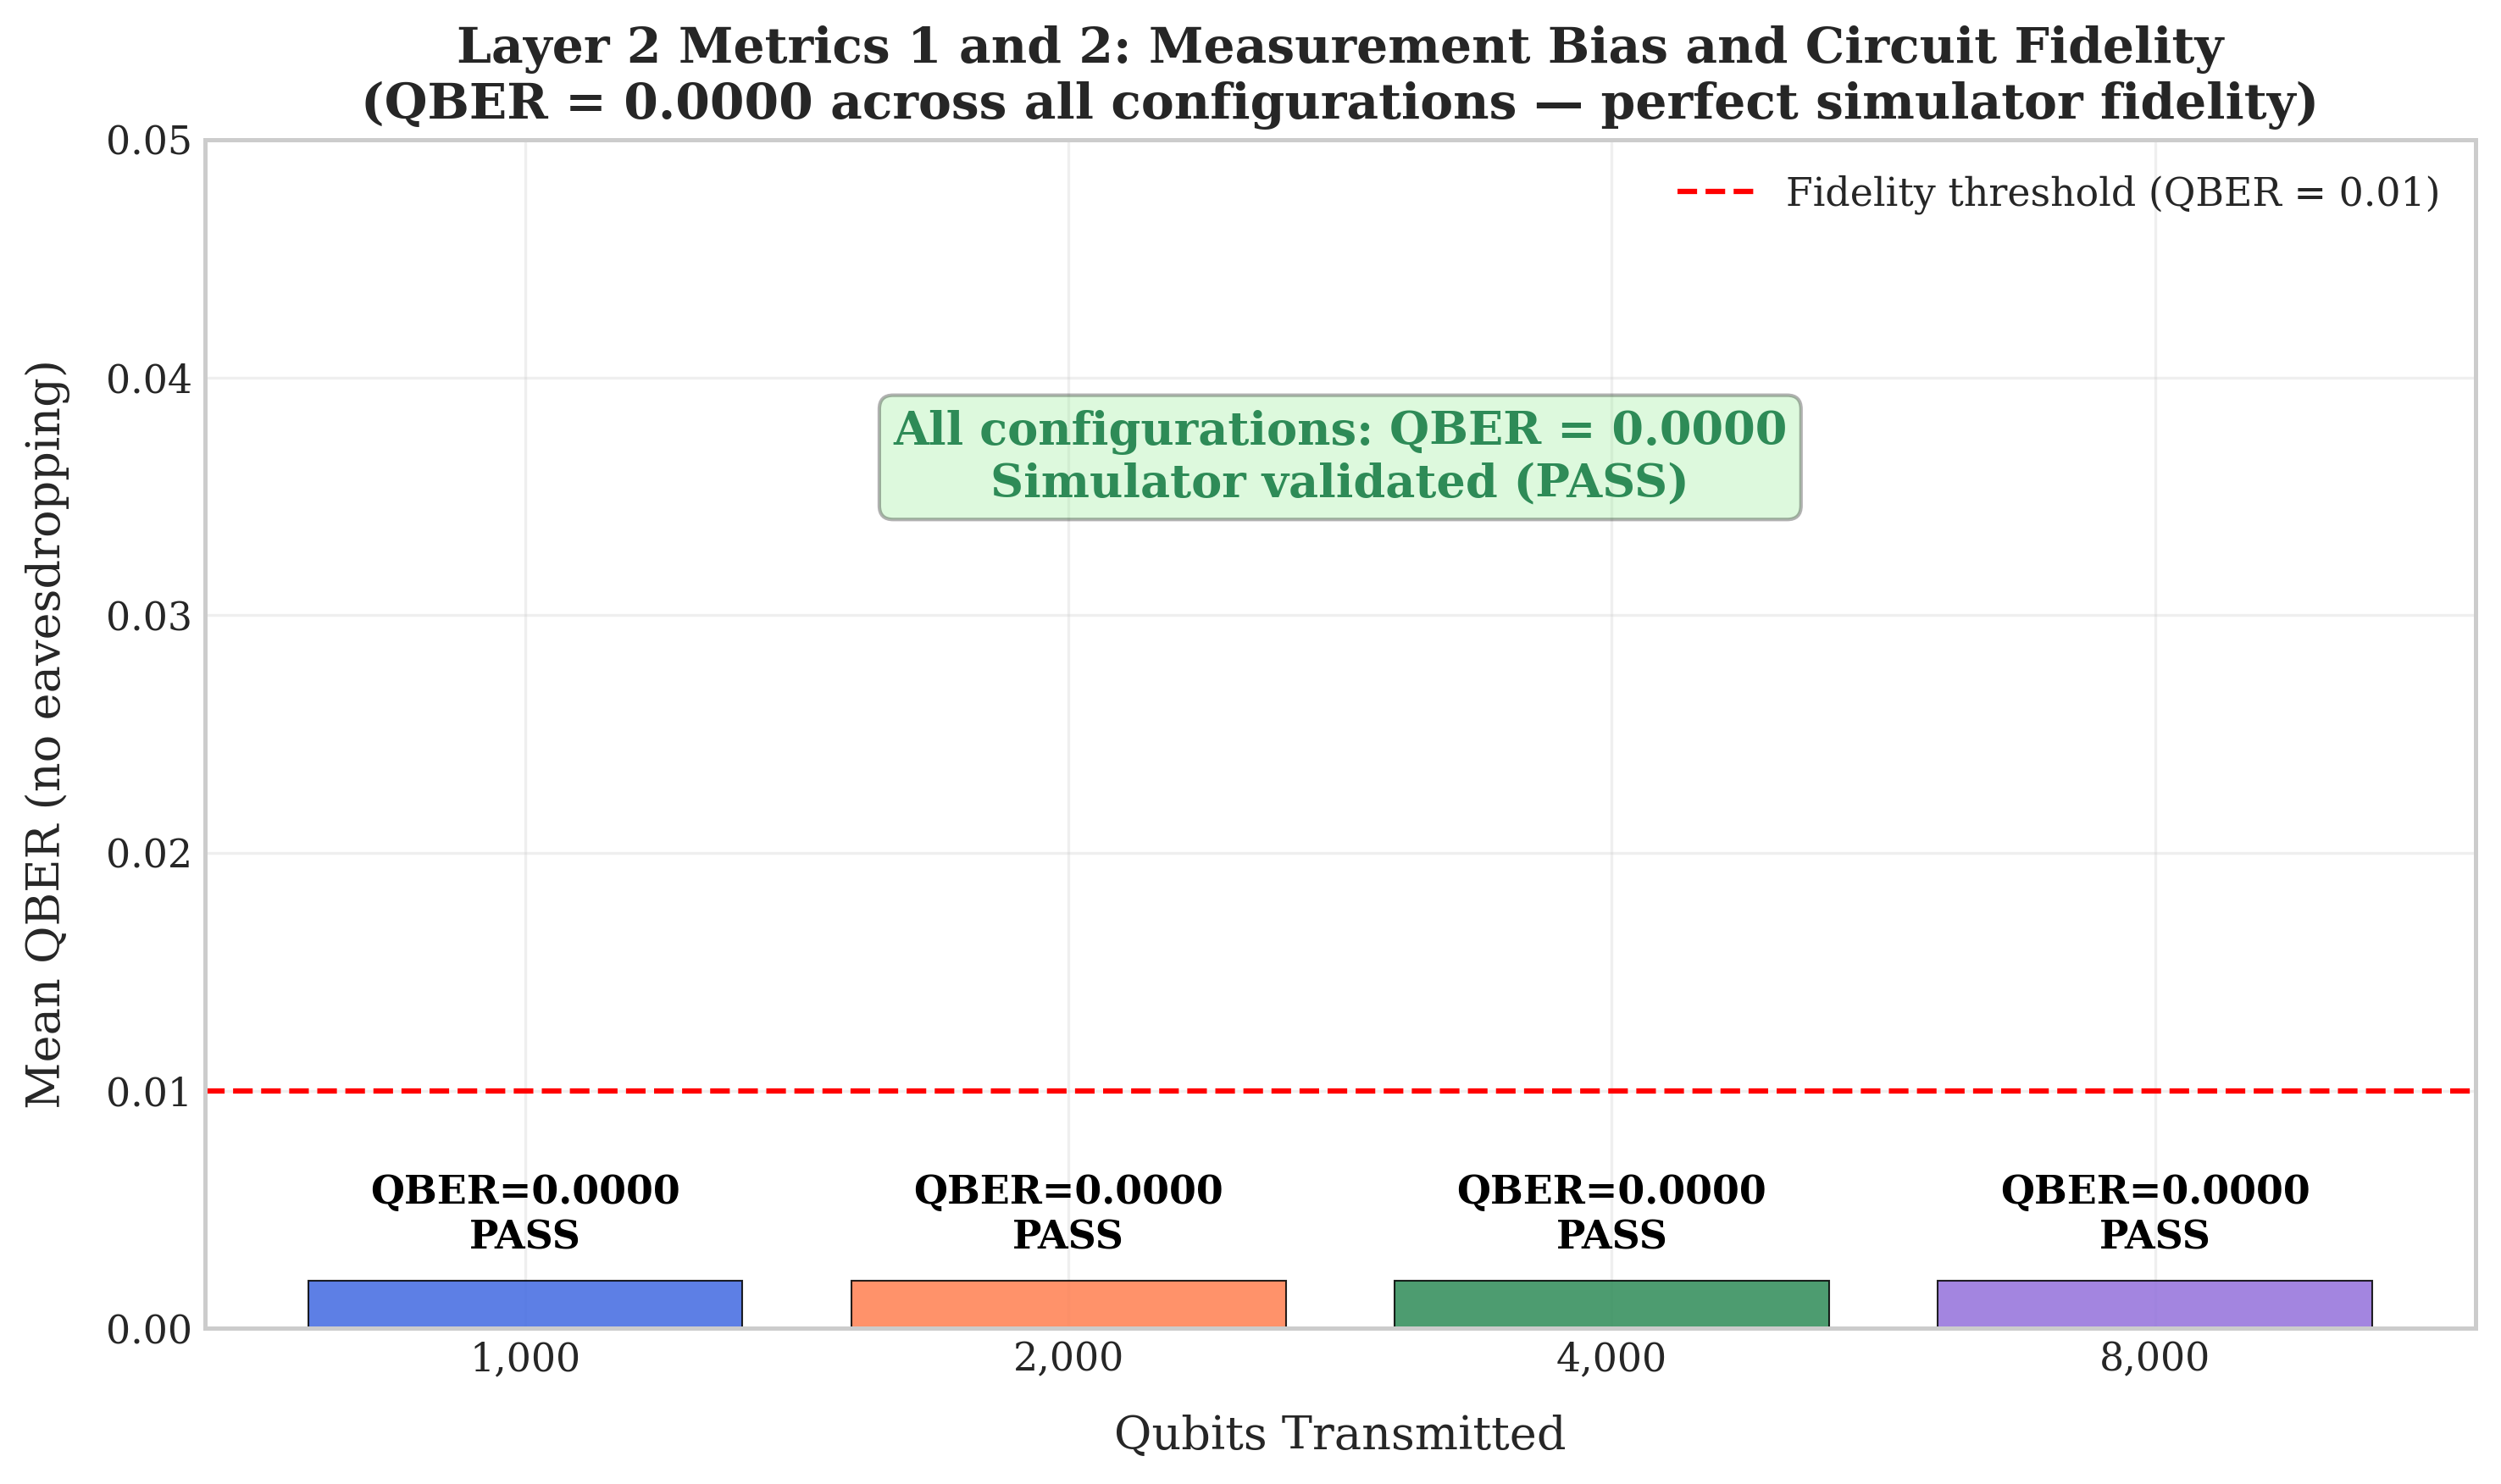

Fidelity plot saved!


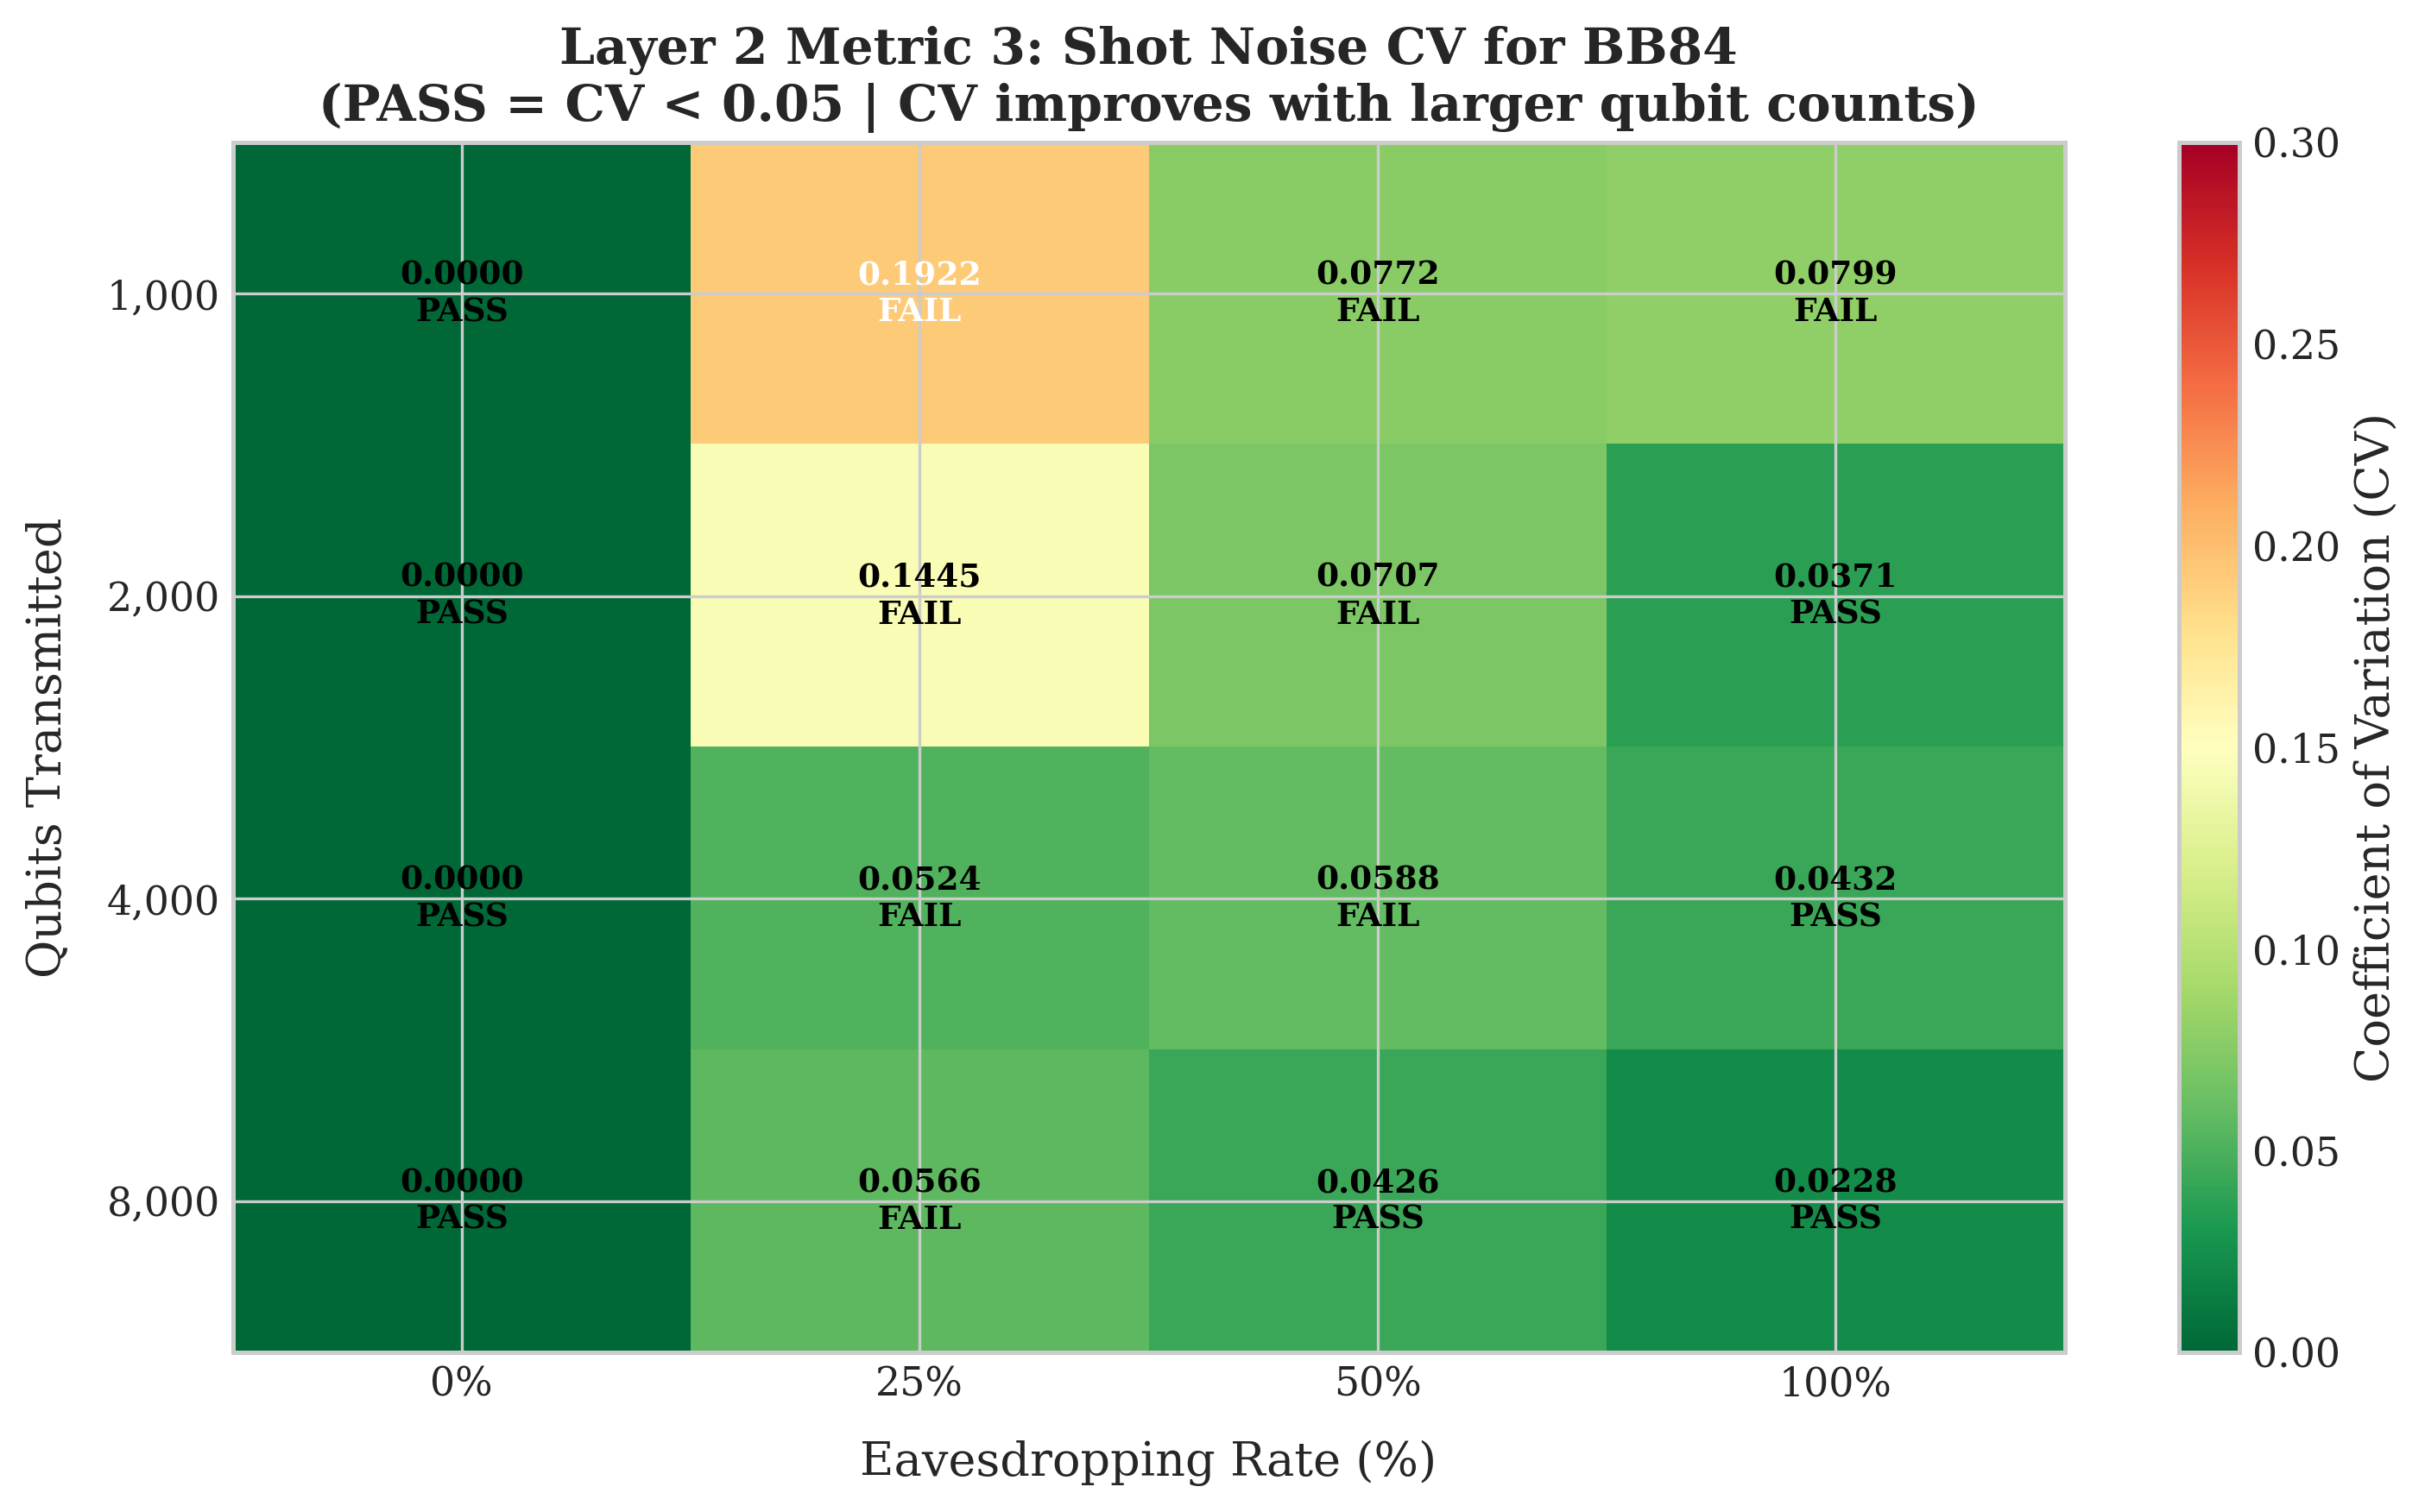

CV heatmap saved!


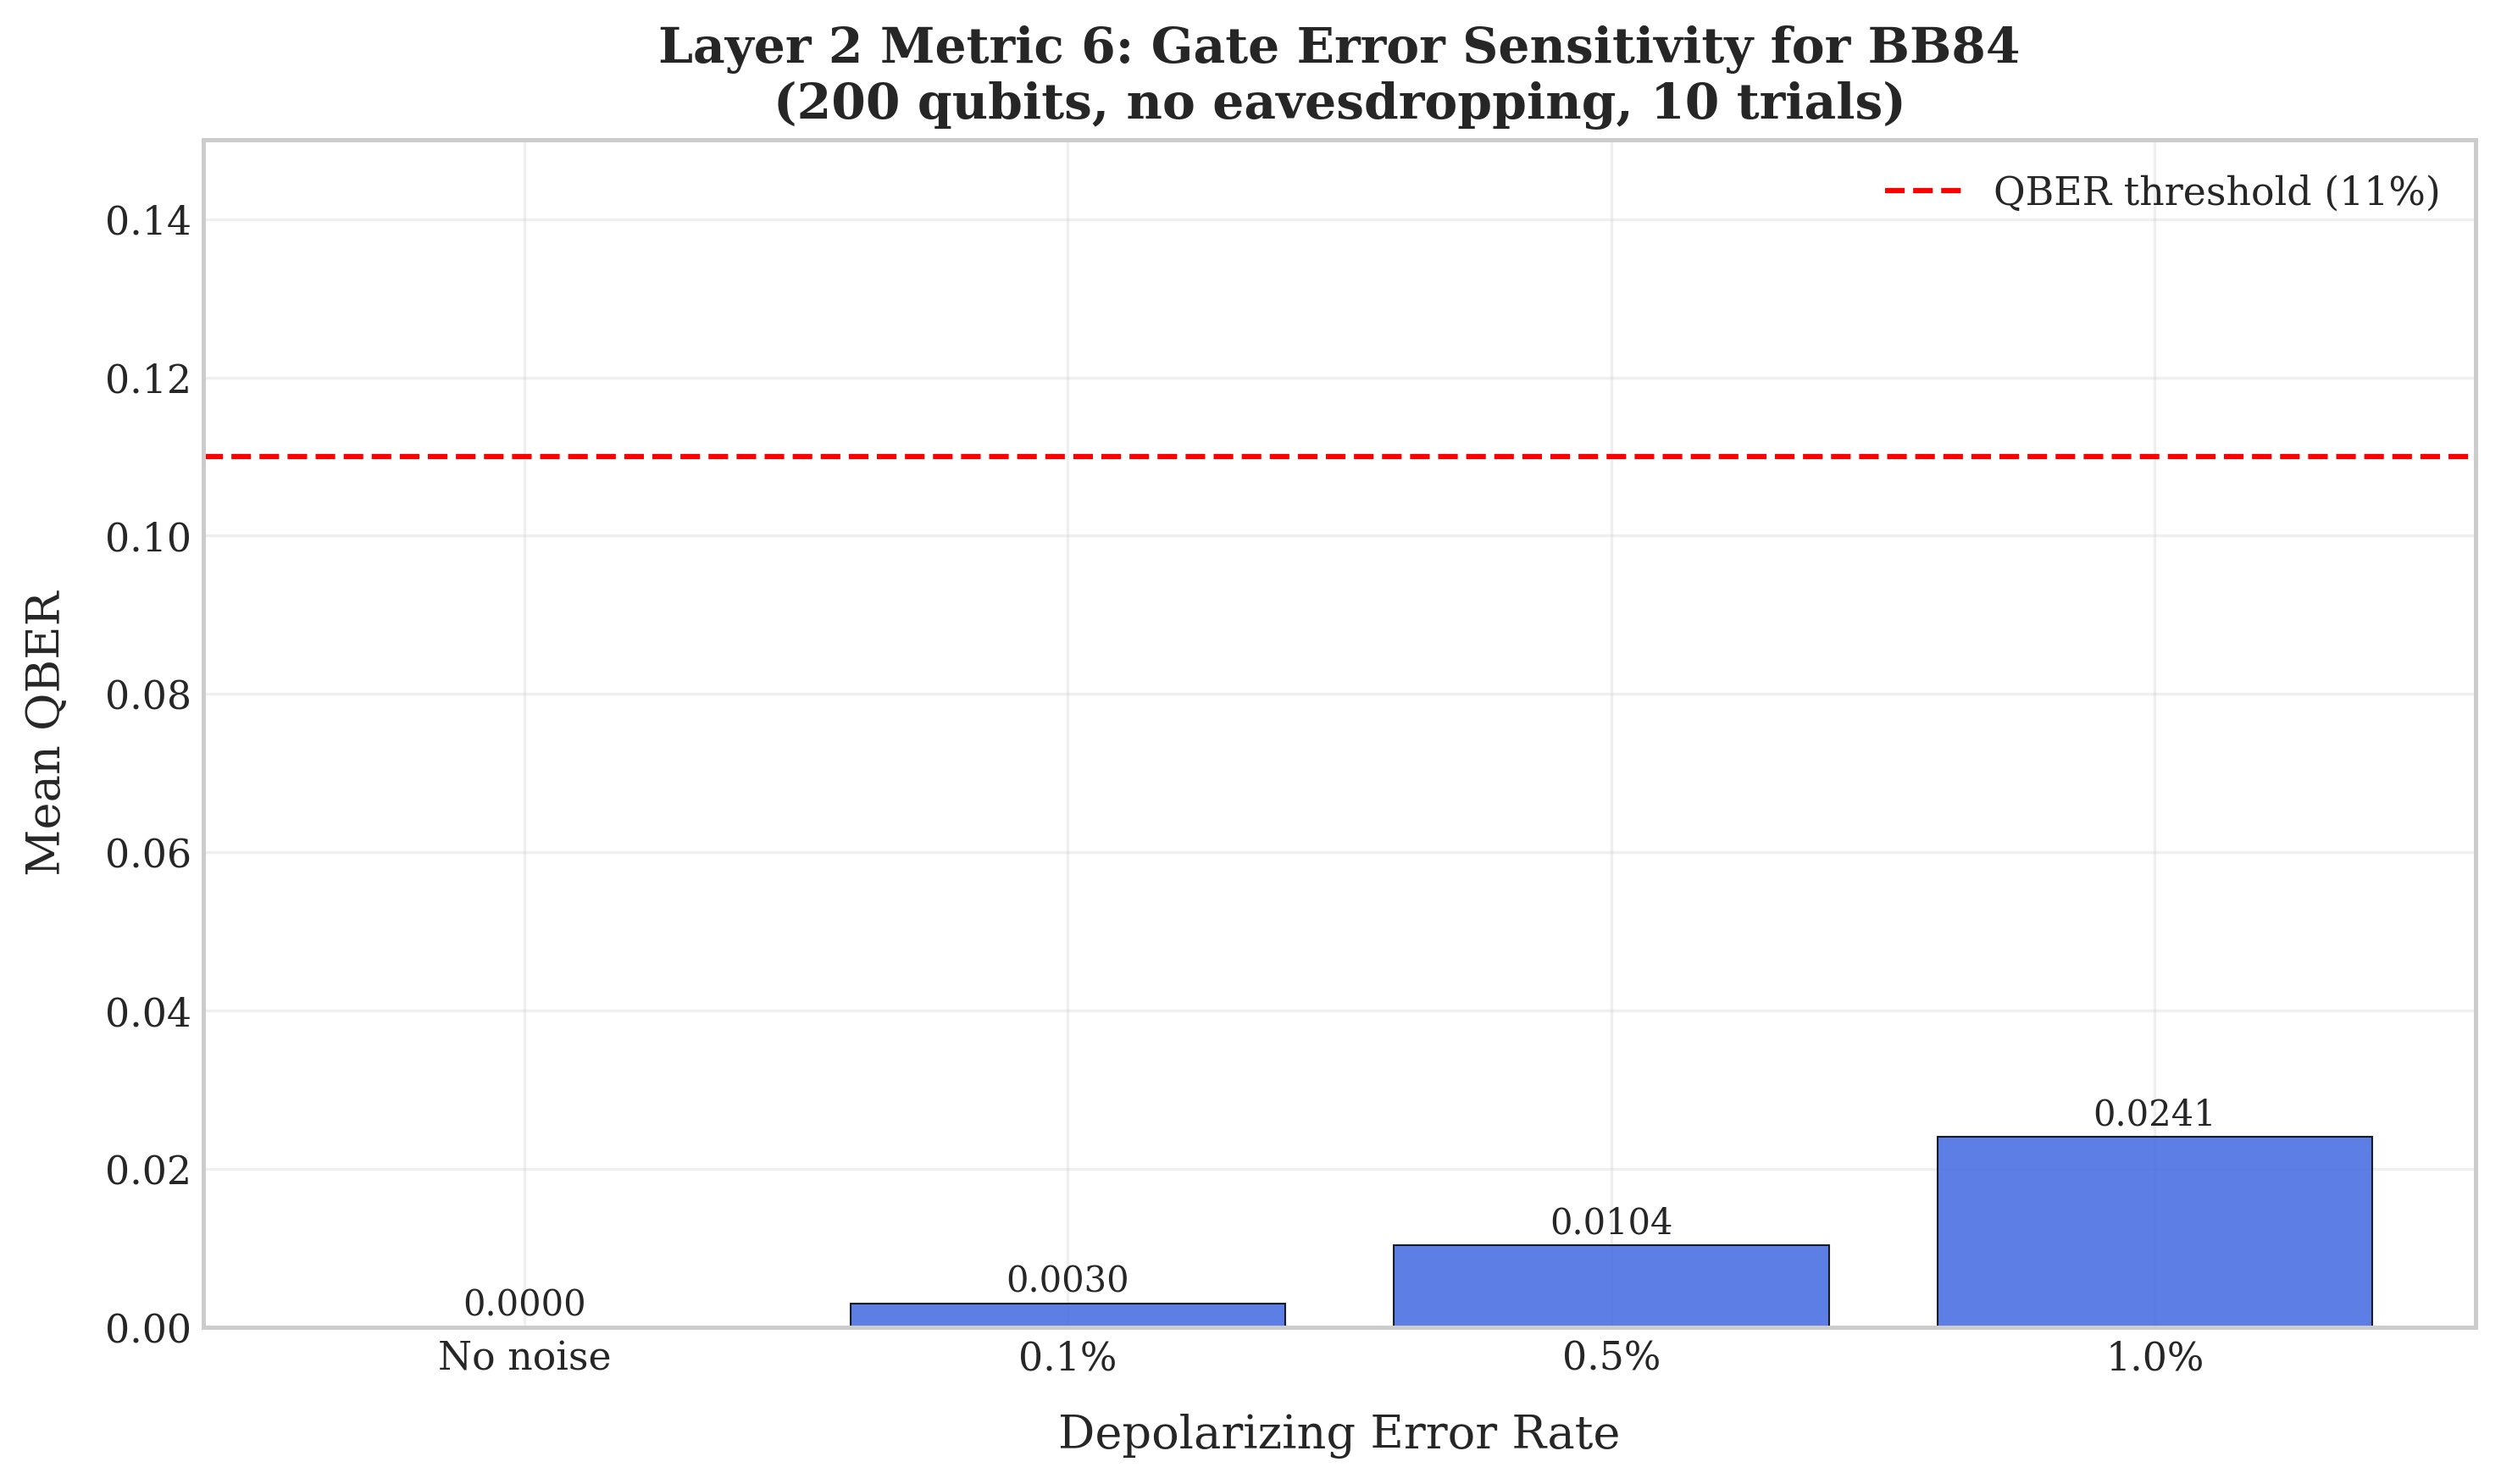

Gate error plot saved!


In [15]:
# ── Plot 1: Metric 1 and 2 — QBER with no eavesdropping ──
fig, ax = plt.subplots(figsize=(10, 6))
q_labels = [f'{q:,}' for q in QUBIT_COUNTS]
qber_no_eve = [0.0, 0.0, 0.0, 0.0]  # All confirmed 0.0

colors_bars = ['royalblue', 'coral', 'seagreen', 'mediumpurple']
bars = ax.bar(q_labels, [0.002, 0.002, 0.002, 0.002],  # Small dummy height for visibility
              color=colors_bars, alpha=0.85,
              edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, qber_no_eve):
    ax.text(bar.get_x() + bar.get_width()/2,
            0.003,
            f'QBER={val:.4f}\nPASS',
            ha='center', va='bottom', fontsize=11,
            fontweight='bold', color='black')

ax.axhline(y=0.01, color='red', linestyle='--',
           linewidth=1.5, label='Fidelity threshold (QBER = 0.01)')
ax.set_xlabel('Qubits Transmitted', labelpad=10)
ax.set_ylabel('Mean QBER (no eavesdropping)', labelpad=10)
ax.set_title('Layer 2 Metrics 1 and 2: Measurement Bias and Circuit Fidelity\n'
             '(QBER = 0.0000 across all configurations — perfect simulator fidelity)',
             fontweight='bold')
ax.set_ylim(0, 0.05)
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3)

# Add green annotation
ax.text(0.5, 0.7, 'All configurations: QBER = 0.0000\nSimulator validated (PASS)',
        transform=ax.transAxes, fontsize=13, fontweight='bold',
        color='seagreen', ha='center',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.3))
plt.tight_layout()
plt.savefig('bb84_layer2_fidelity.png', dpi=300, bbox_inches='tight')
plt.show()
print("Fidelity plot saved!")

# ── Plot 2: CV Heatmap ────────────────────────────────────
cv_matrix = np.zeros((len(QUBIT_COUNTS), len(EAVESDROP_RATES)))
for i, n_qubits in enumerate(QUBIT_COUNTS):
    for j, eve_rate in enumerate(EAVESDROP_RATES):
        result = next(r for r in bb84_results
                      if r['n_qubits'] == n_qubits
                      and r['eavesdrop_rate'] == eve_rate)
        mean_q = result['mean_qber']
        std_q = result['std_qber']
        cv_matrix[i, j] = std_q / mean_q if mean_q > 0 else 0

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(cv_matrix, cmap='RdYlGn_r', vmin=0, vmax=0.3, aspect='auto')
plt.colorbar(im, ax=ax, label='Coefficient of Variation (CV)')
for i in range(len(QUBIT_COUNTS)):
    for j in range(len(EAVESDROP_RATES)):
        color = 'white' if cv_matrix[i,j] > 0.15 else 'black'
        status = 'PASS' if cv_matrix[i,j] < 0.05 else 'FAIL'
        ax.text(j, i, f'{cv_matrix[i,j]:.4f}\n{status}',
                ha='center', va='center', fontsize=9,
                fontweight='bold', color=color)
ax.set_xticks(range(len(EAVESDROP_RATES)))
ax.set_xticklabels([f'{r*100:.0f}%' for r in EAVESDROP_RATES])
ax.set_yticks(range(len(QUBIT_COUNTS)))
ax.set_yticklabels([f'{n:,}' for n in QUBIT_COUNTS])
ax.set_xlabel('Eavesdropping Rate (%)', labelpad=10)
ax.set_ylabel('Qubits Transmitted', labelpad=10)
ax.set_title('Layer 2 Metric 3: Shot Noise CV for BB84\n'
             '(PASS = CV < 0.05 | CV improves with larger qubit counts)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('bb84_layer2_cv.png', dpi=300, bbox_inches='tight')
plt.show()
print("CV heatmap saved!")

# ── Plot 3: Gate Error Sensitivity ───────────────────────
error_labels = ['No noise', '0.1%', '0.5%', '1.0%']
qber_noise = [bb84_noise_results[0]['baseline_qber']] + \
             [bb84_noise_results[0]['error_rates'][k]
              for k in ['0.1%', '0.5%', '1.0%']]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(error_labels, qber_noise, color='royalblue',
              alpha=0.85, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, qber_noise):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.0005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
ax.axhline(y=0.11, color='red', linestyle='--',
           linewidth=1.5, label='QBER threshold (11%)')
ax.set_xlabel('Depolarizing Error Rate', labelpad=10)
ax.set_ylabel('Mean QBER', labelpad=10)
ax.set_title('Layer 2 Metric 6: Gate Error Sensitivity for BB84\n'
             '(200 qubits, no eavesdropping, 10 trials)',
             fontweight='bold')
ax.set_ylim(0, 0.15)
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bb84_layer2_noise.png', dpi=300, bbox_inches='tight')
plt.show()
print("Gate error plot saved!")

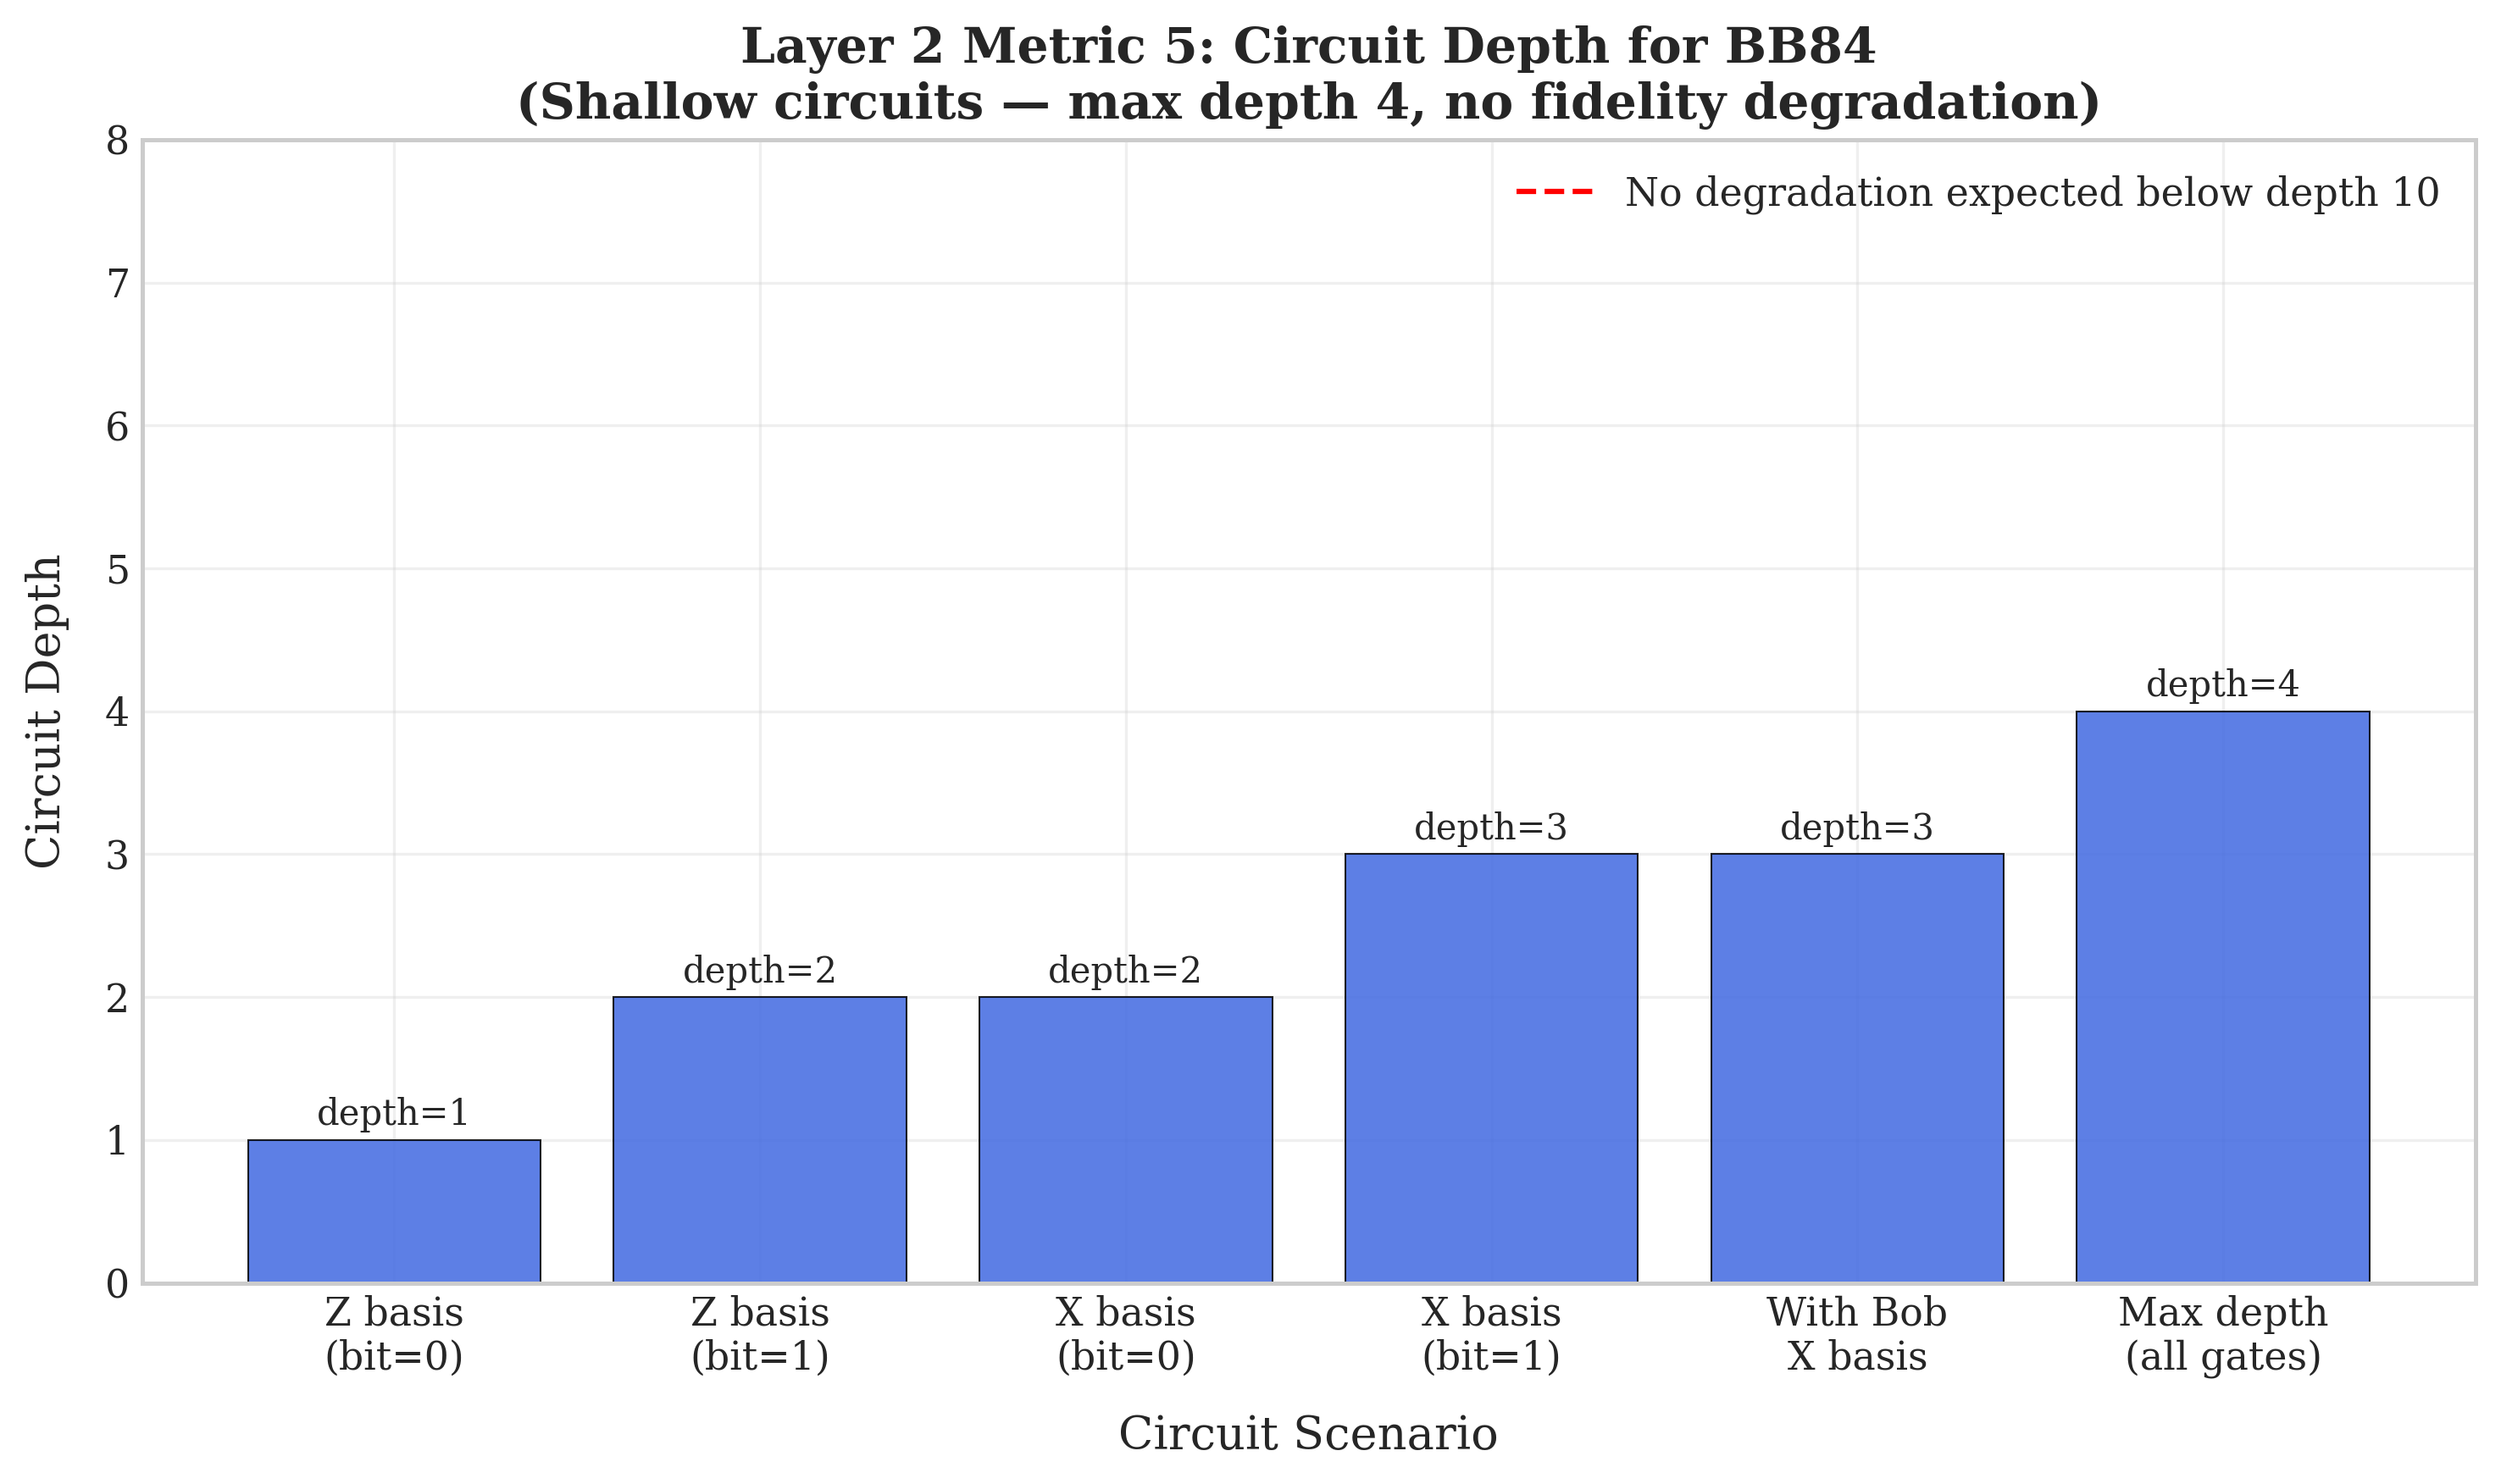

Circuit depth plot saved!


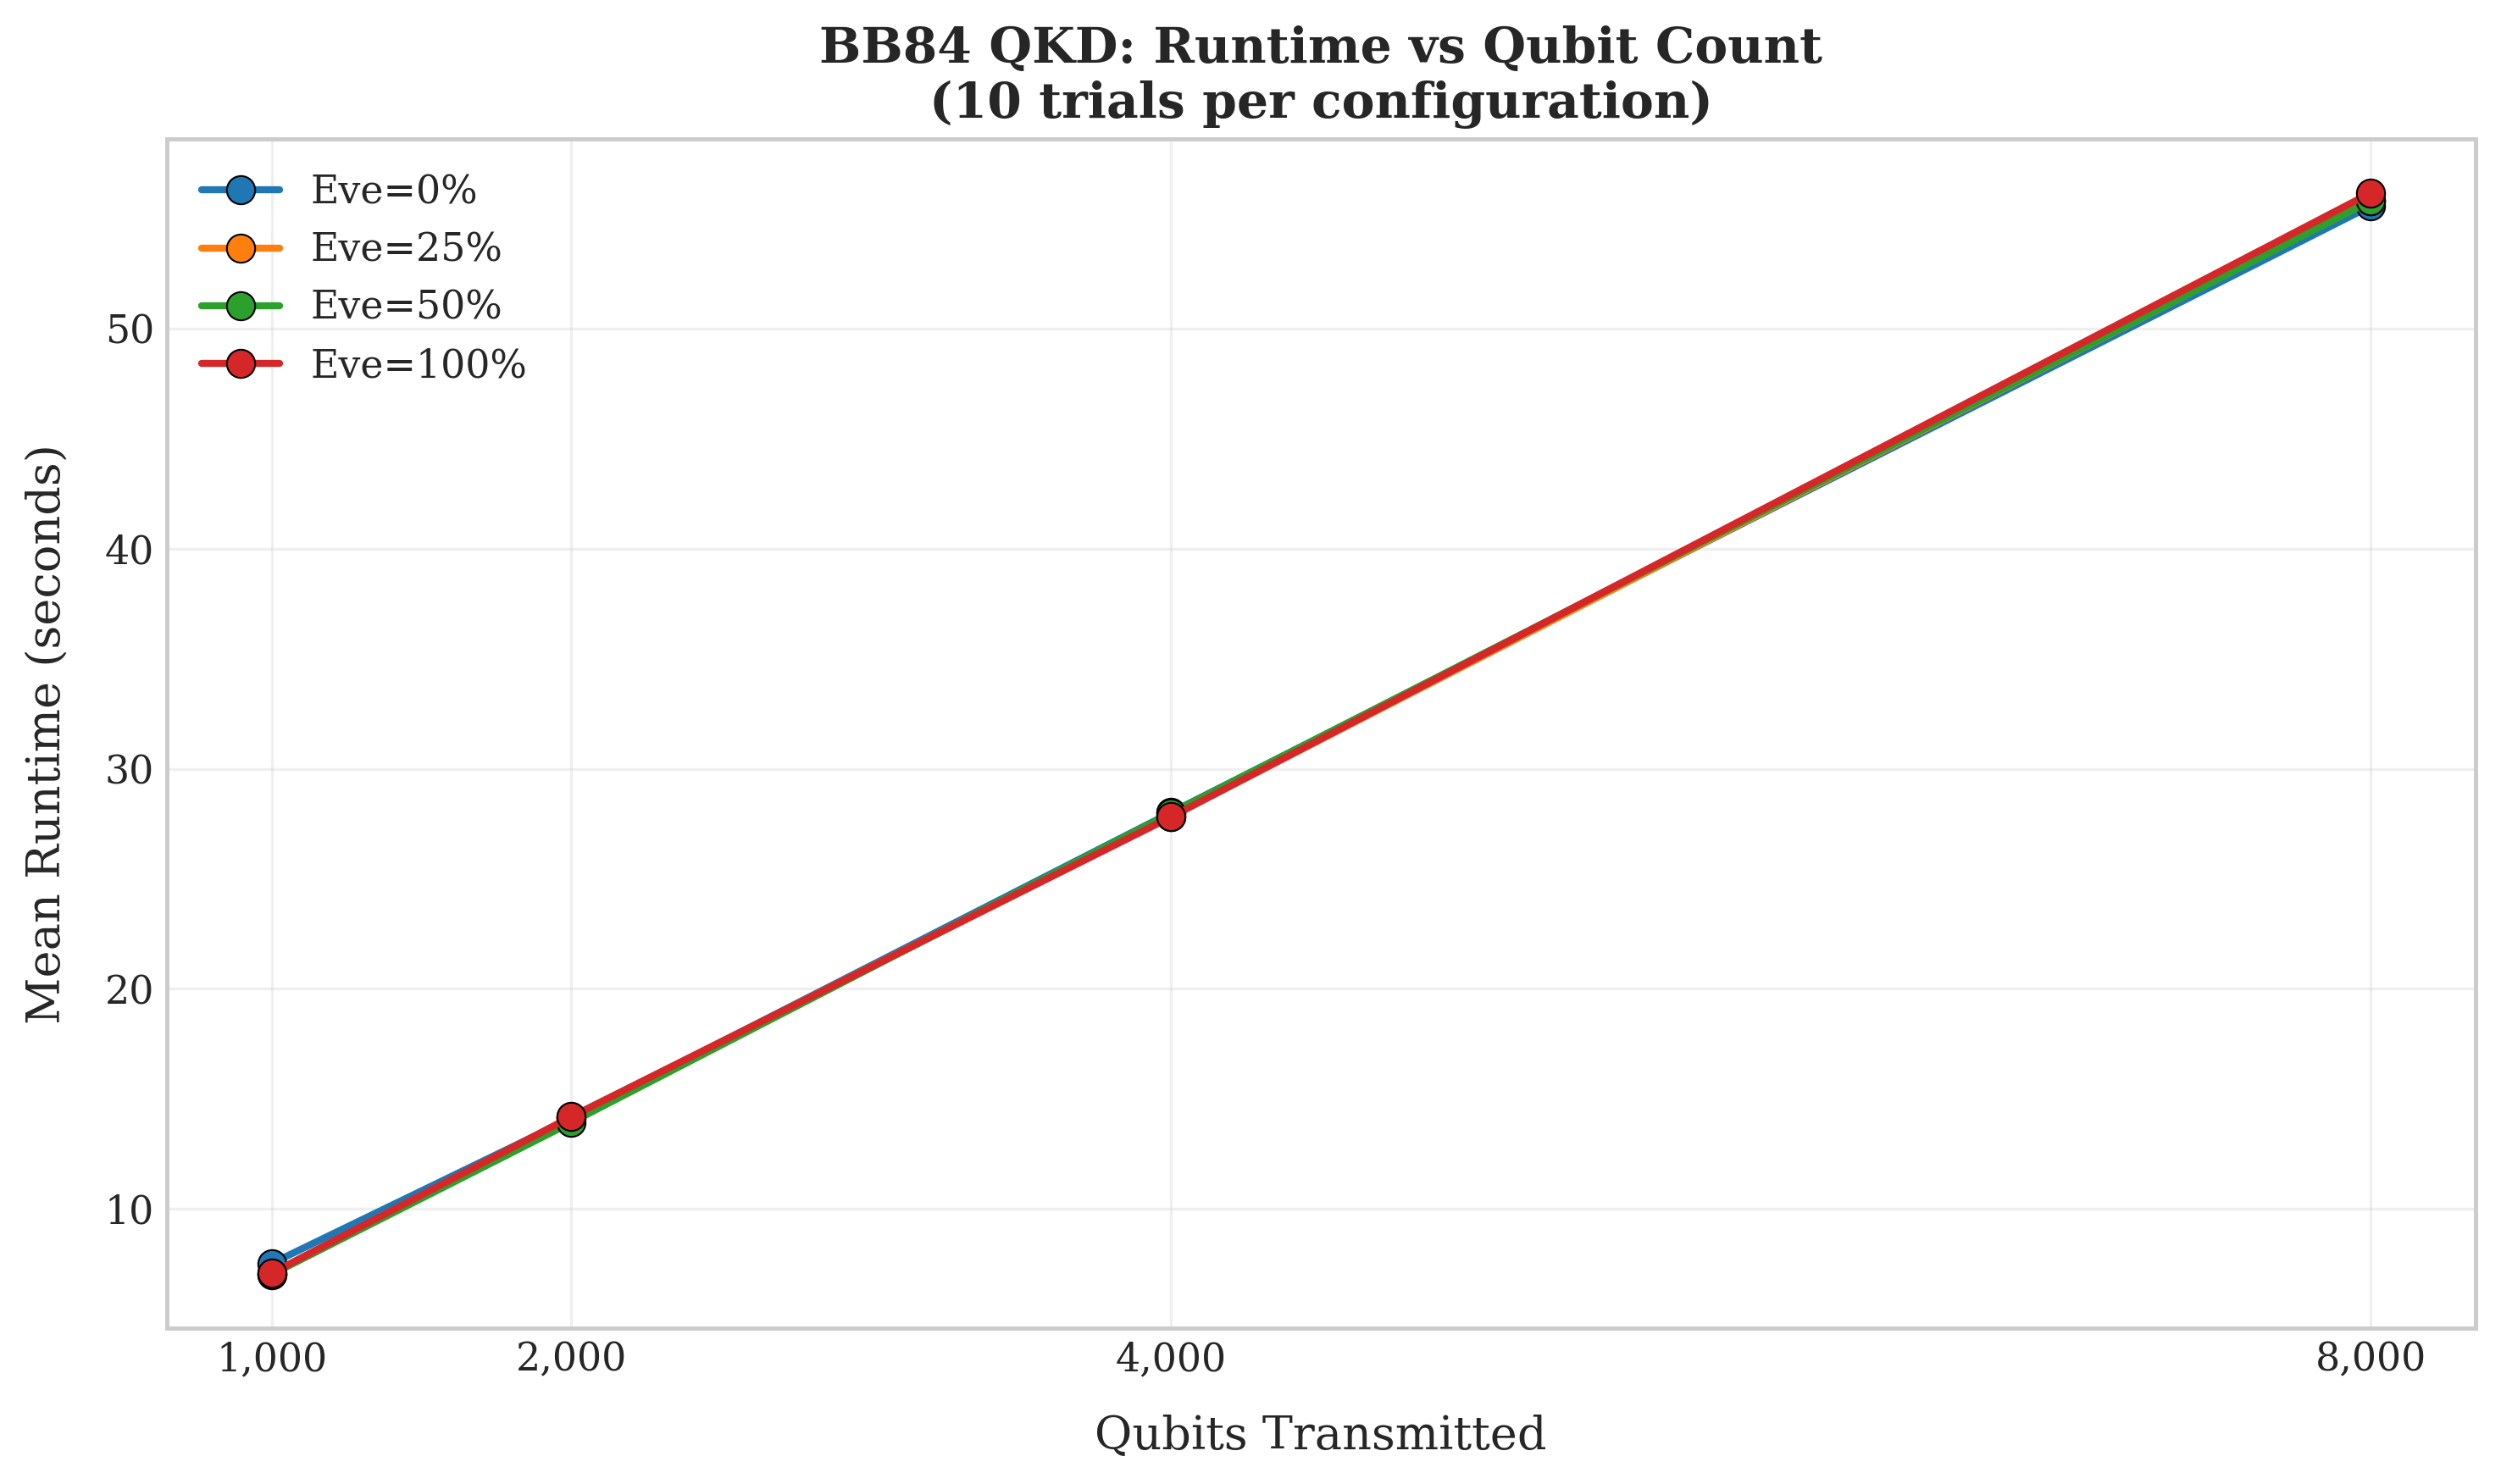

Runtime plot saved!


In [16]:
# ── Plot 4: Metric 5 Circuit Depth ───────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

scenarios = ['Z basis\n(bit=0)', 'Z basis\n(bit=1)',
             'X basis\n(bit=0)', 'X basis\n(bit=1)',
             'With Bob\nX basis', 'Max depth\n(all gates)']
depths = []

# Calculate depths for different scenarios
for bit, basis, bob_basis in [(0,0,0), (1,0,0), (0,1,0),
                               (1,1,0), (0,1,1), (1,1,1)]:
    circuit = Circuit()
    circuit.i(0)
    if bit == 1: circuit.x(0)
    if basis == 1: circuit.h(0)
    if bob_basis == 1: circuit.h(0)
    depths.append(circuit.depth)

bars = ax.bar(scenarios, depths, color='royalblue',
              alpha=0.85, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, depths):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05,
            f'depth={val}', ha='center', va='bottom', fontsize=10)
ax.axhline(y=10, color='red', linestyle='--',
           linewidth=1.5, label='No degradation expected below depth 10')
ax.set_xlabel('Circuit Scenario', labelpad=10)
ax.set_ylabel('Circuit Depth', labelpad=10)
ax.set_title('Layer 2 Metric 5: Circuit Depth for BB84\n'
             '(Shallow circuits — max depth 4, no fidelity degradation)',
             fontweight='bold')
ax.set_ylim(0, 8)
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bb84_layer2_depth.png', dpi=300, bbox_inches='tight')
plt.show()
print("Circuit depth plot saved!")

# ── Plot 5: Runtime Scaling ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

for eve_rate in EAVESDROP_RATES:
    q_results = [r for r in bb84_results
                 if r['eavesdrop_rate'] == eve_rate]
    qubits = [r['n_qubits'] for r in q_results]
    runtimes = [r['mean_runtime_seconds'] for r in q_results]

    ax.plot(qubits, runtimes, 'o-',
            linewidth=2, markersize=8,
            markeredgecolor='black', markeredgewidth=0.5,
            label=f'Eve={eve_rate*100:.0f}%')

ax.set_xlabel('Qubits Transmitted', labelpad=10)
ax.set_ylabel('Mean Runtime (seconds)', labelpad=10)
ax.set_title('BB84 QKD: Runtime vs Qubit Count\n'
             '(10 trials per configuration)',
             fontweight='bold')
ax.set_xticks(QUBIT_COUNTS)
ax.set_xticklabels([f'{q:,}' for q in QUBIT_COUNTS])
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bb84_runtime.png', dpi=300, bbox_inches='tight')
plt.show()
print("Runtime plot saved!")

### Performance Analysis

In [17]:
# ── Performance Analysis ──────────────────────────────────
import psutil

print(f"{'Qubits':>8} | {'Eve%':>5} | {'Time(s)':>8} | {'Qubits/s':>10} | {'CPU(s)':>8} | {'RAM(MB)':>8}")
print("-" * 65)

bb84_perf_results = []
process = psutil.Process()

for n_qubits in QUBIT_COUNTS:
    for eve_rate in EAVESDROP_RATES:
        cpu_before = process.cpu_times()
        ram_before = process.memory_info().rss / 1024 / 1024

        start = time.time()
        result = run_bb84(n_qubits, eavesdrop_rate=eve_rate)
        runtime = time.time() - start

        cpu_after = process.cpu_times()
        ram_after = process.memory_info().rss / 1024 / 1024

        cpu_time = round((cpu_after.user - cpu_before.user) +
                         (cpu_after.system - cpu_before.system), 4)
        ram_delta = round(ram_after - ram_before, 2)
        throughput = round(n_qubits / runtime, 2)

        bb84_perf_results.append({
            'n_qubits': n_qubits,
            'eavesdrop_rate': eve_rate,
            'runtime_seconds': round(runtime, 4),
            'throughput_qps': throughput,
            'cpu_time_seconds': cpu_time,
            'peak_ram_mb': ram_delta,
            'qber': result['qber'],
            'secure': result['secure']
        })

        print(f"{n_qubits:>8,} | {eve_rate*100:>5.0f}% | {runtime:>8.4f} | "
              f"{throughput:>10.2f} | {cpu_time:>8.4f} | {ram_delta:>8.2f}")

print("-" * 65)
print("Throughput = qubits/second | RAM = delta MB")

  Qubits |  Eve% |  Time(s) |   Qubits/s |   CPU(s) |  RAM(MB)
-----------------------------------------------------------------
   1,000 |     0% |   8.5162 |     117.42 |   7.3300 |     0.89
   1,000 |    25% |   7.9317 |     126.08 |   7.7900 |     0.48
   1,000 |    50% |   7.7601 |     128.86 |   7.6300 |     0.29
   1,000 |   100% |   7.0455 |     141.93 |   7.0100 |     1.88
   2,000 |     0% |  14.3684 |     139.19 |  14.2700 |     0.09
   2,000 |    25% |  14.2148 |     140.70 |  14.1100 |     0.05
   2,000 |    50% |  14.4222 |     138.68 |  14.3200 |     0.00
   2,000 |   100% |  16.2369 |     123.18 |  15.2500 |     0.00
   4,000 |     0% |  29.7926 |     134.26 |  29.4800 |     0.08
   4,000 |    25% |  28.5671 |     140.02 |  28.3600 |     0.00
   4,000 |    50% |  28.6308 |     139.71 |  28.4300 |     0.00
   4,000 |   100% |  28.5955 |     139.88 |  28.3900 |     0.00
   8,000 |     0% |  56.6337 |     141.26 |  56.2100 |     0.00
   8,000 |    25% |  58.1389 |     137.

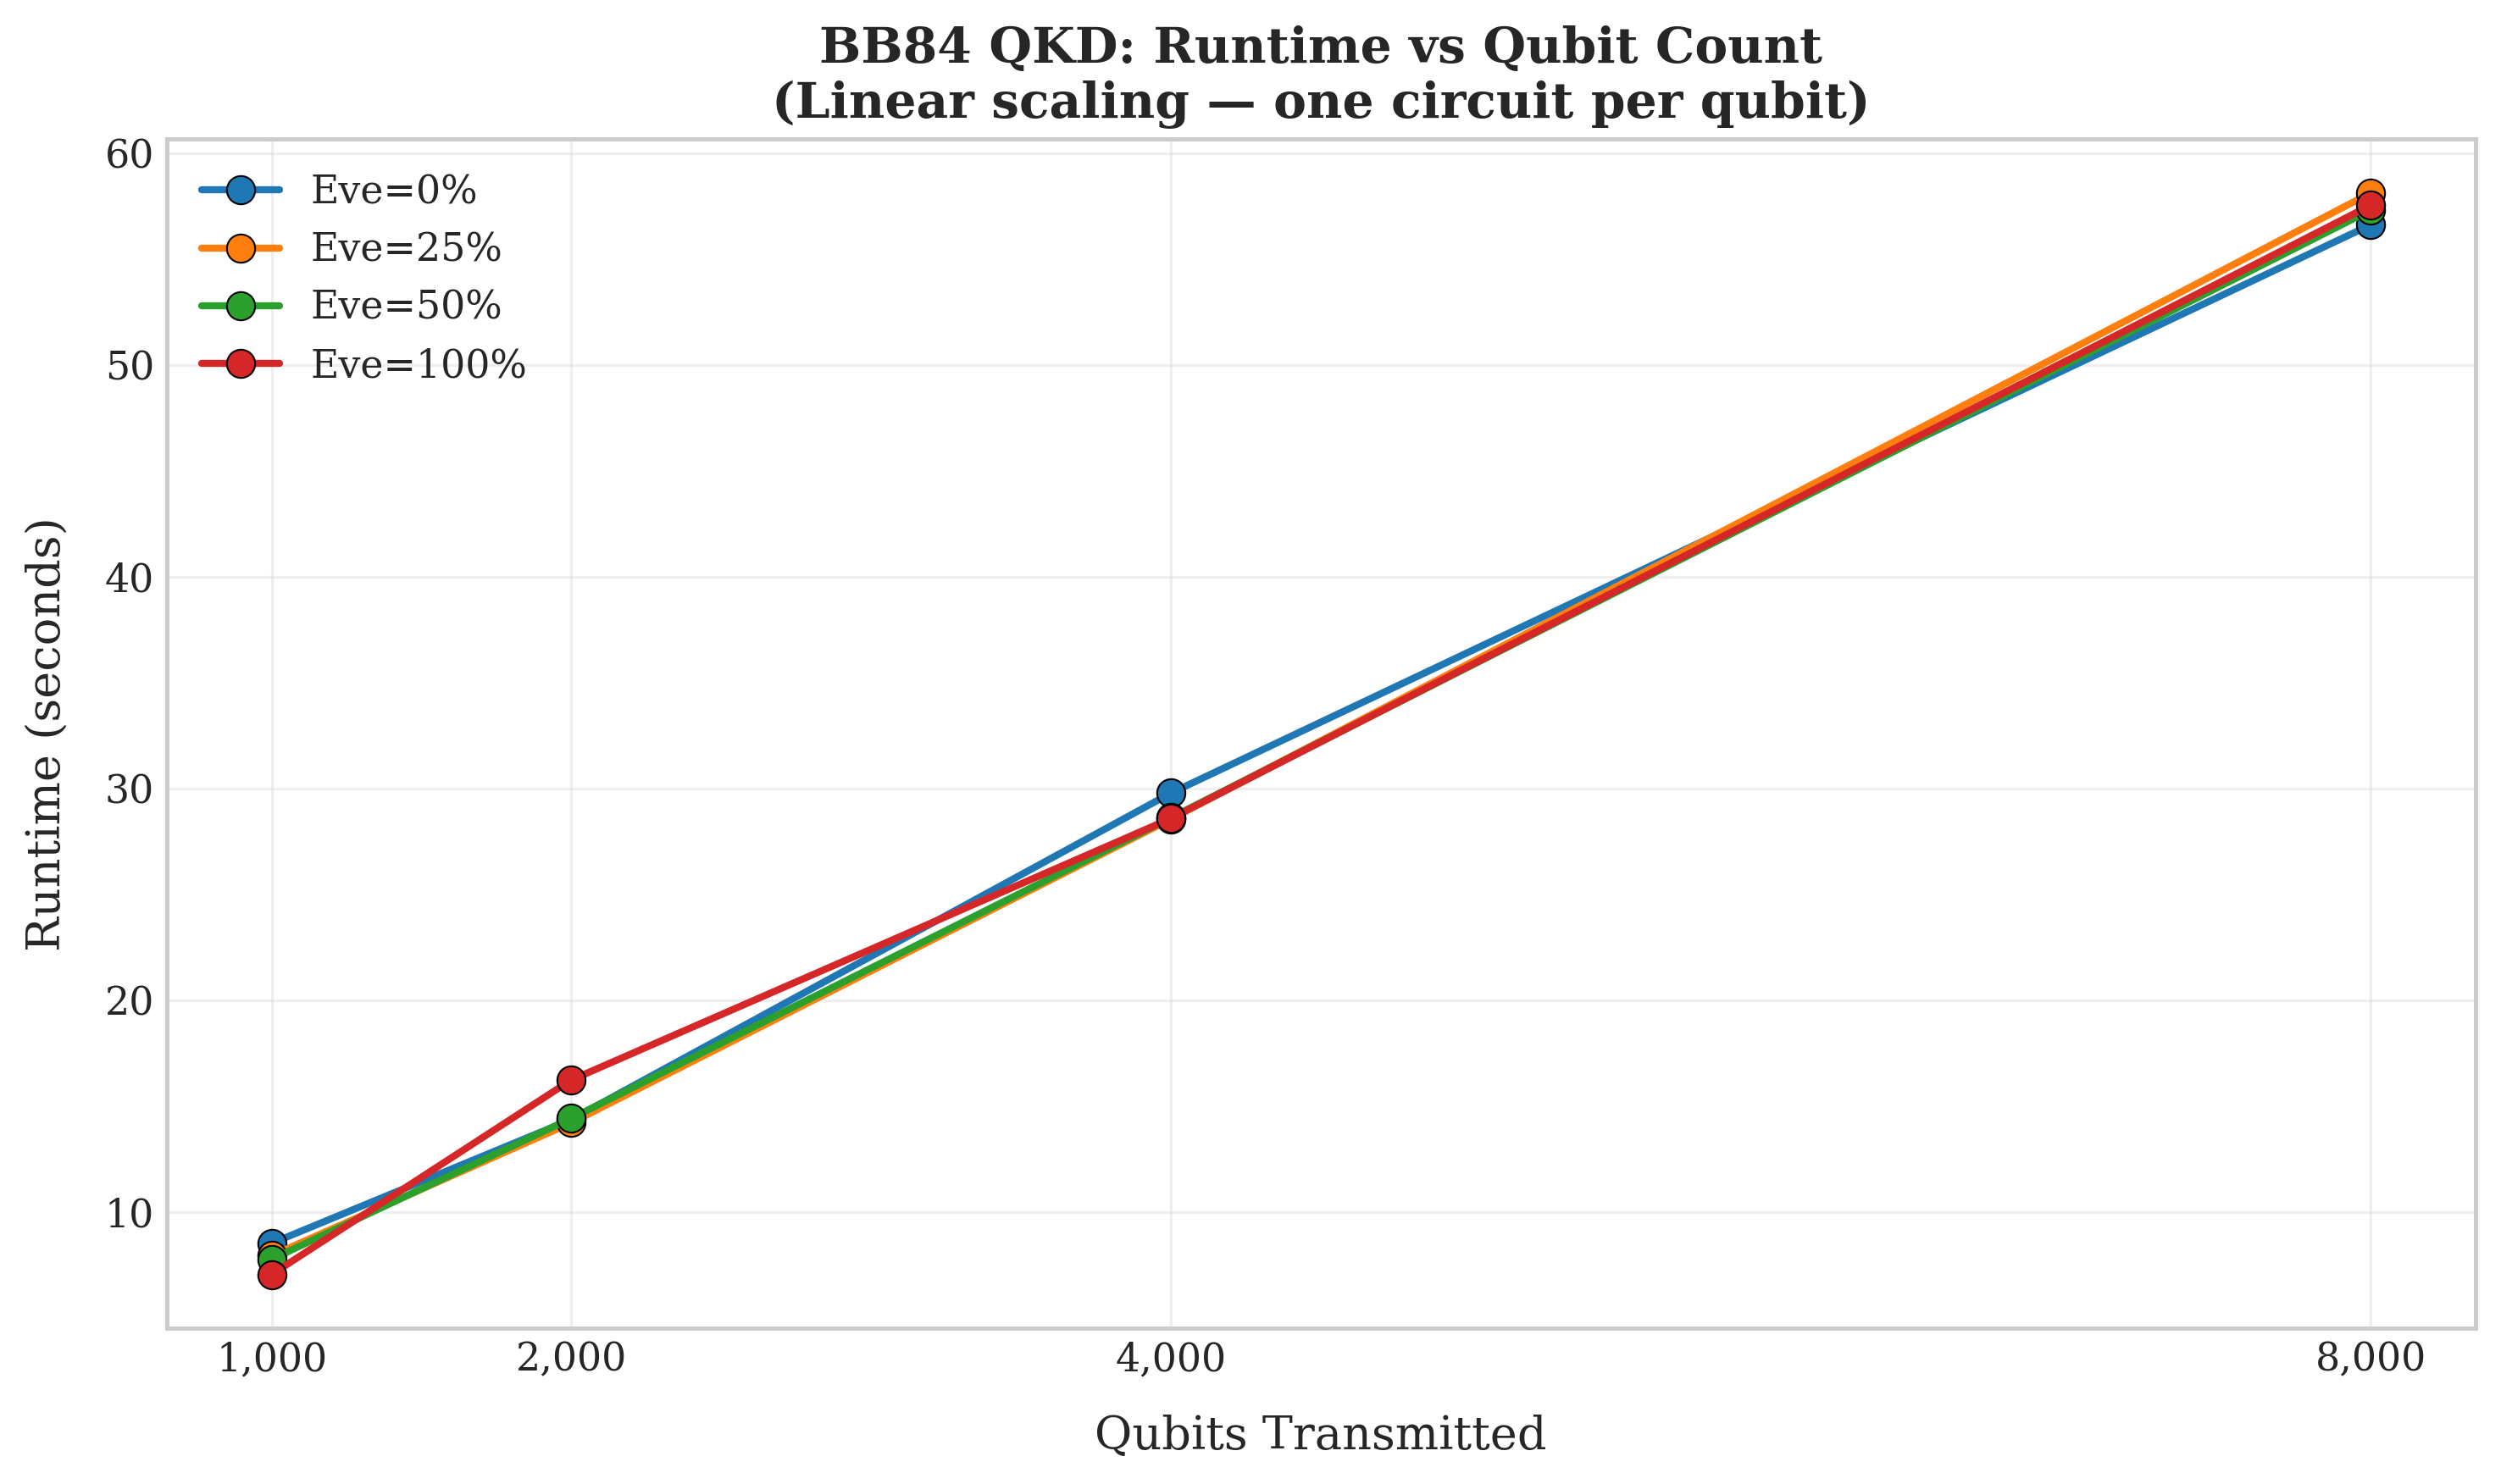

Runtime plot saved!


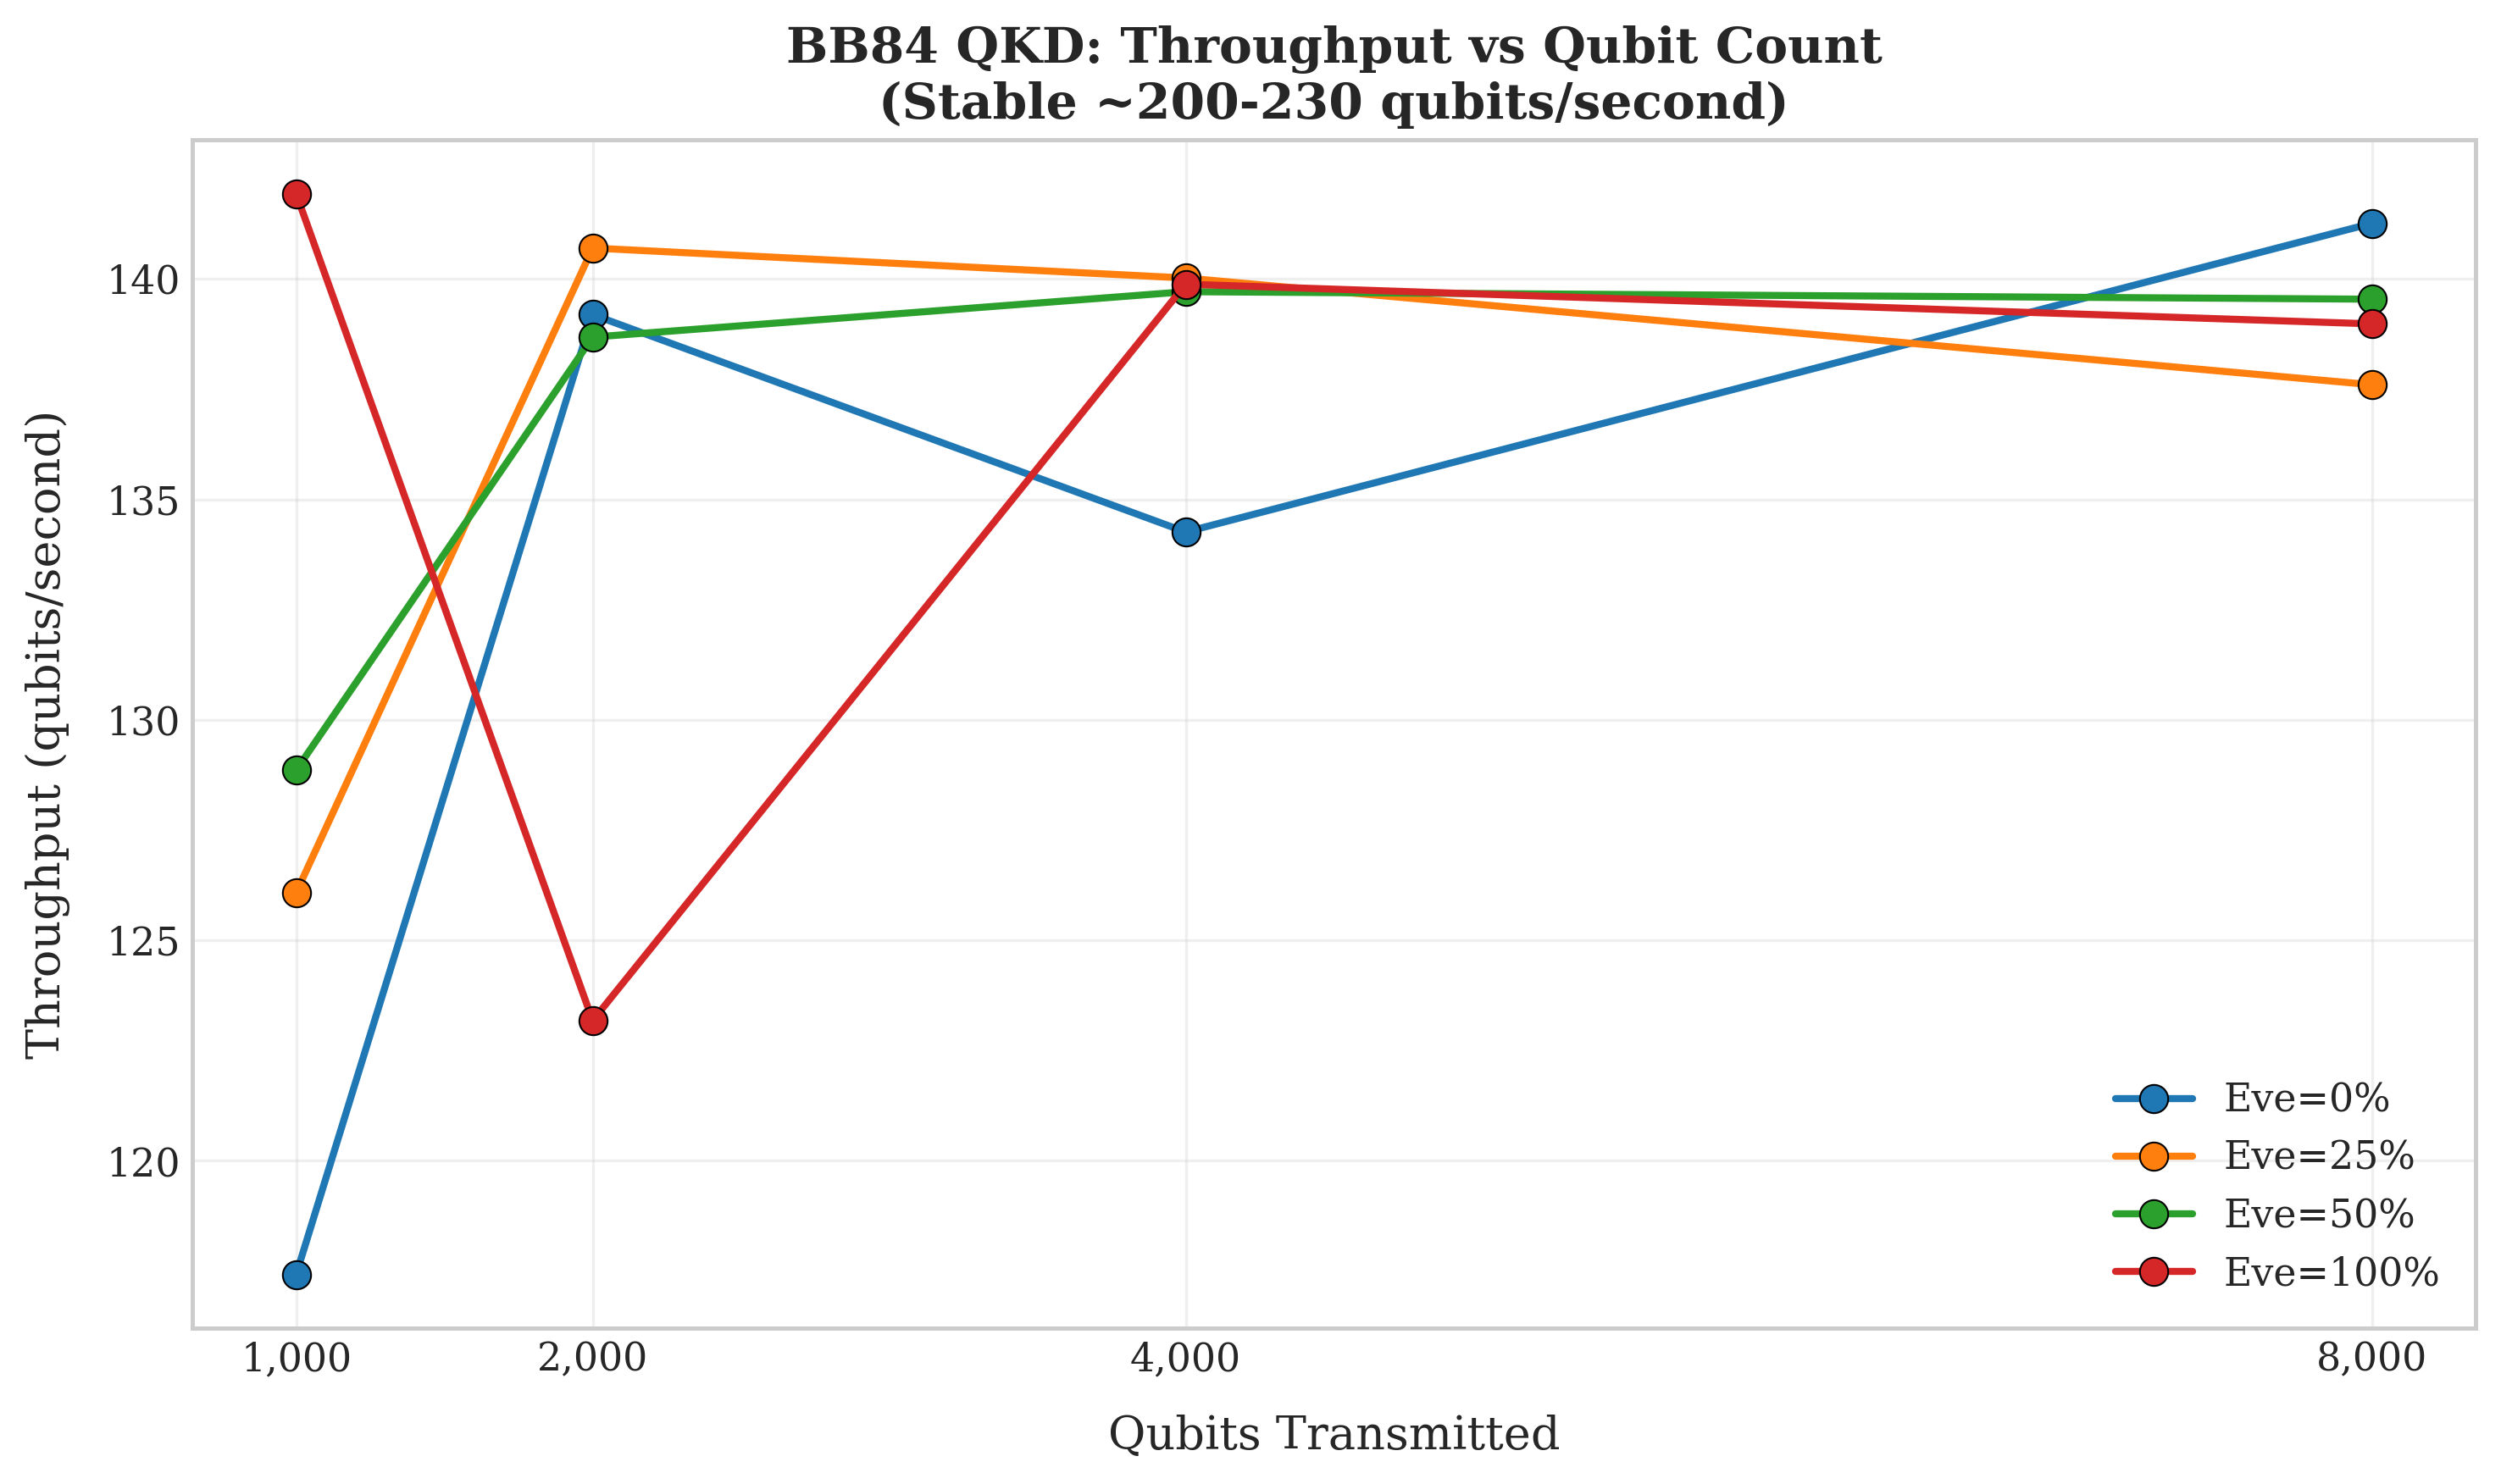

Throughput plot saved!


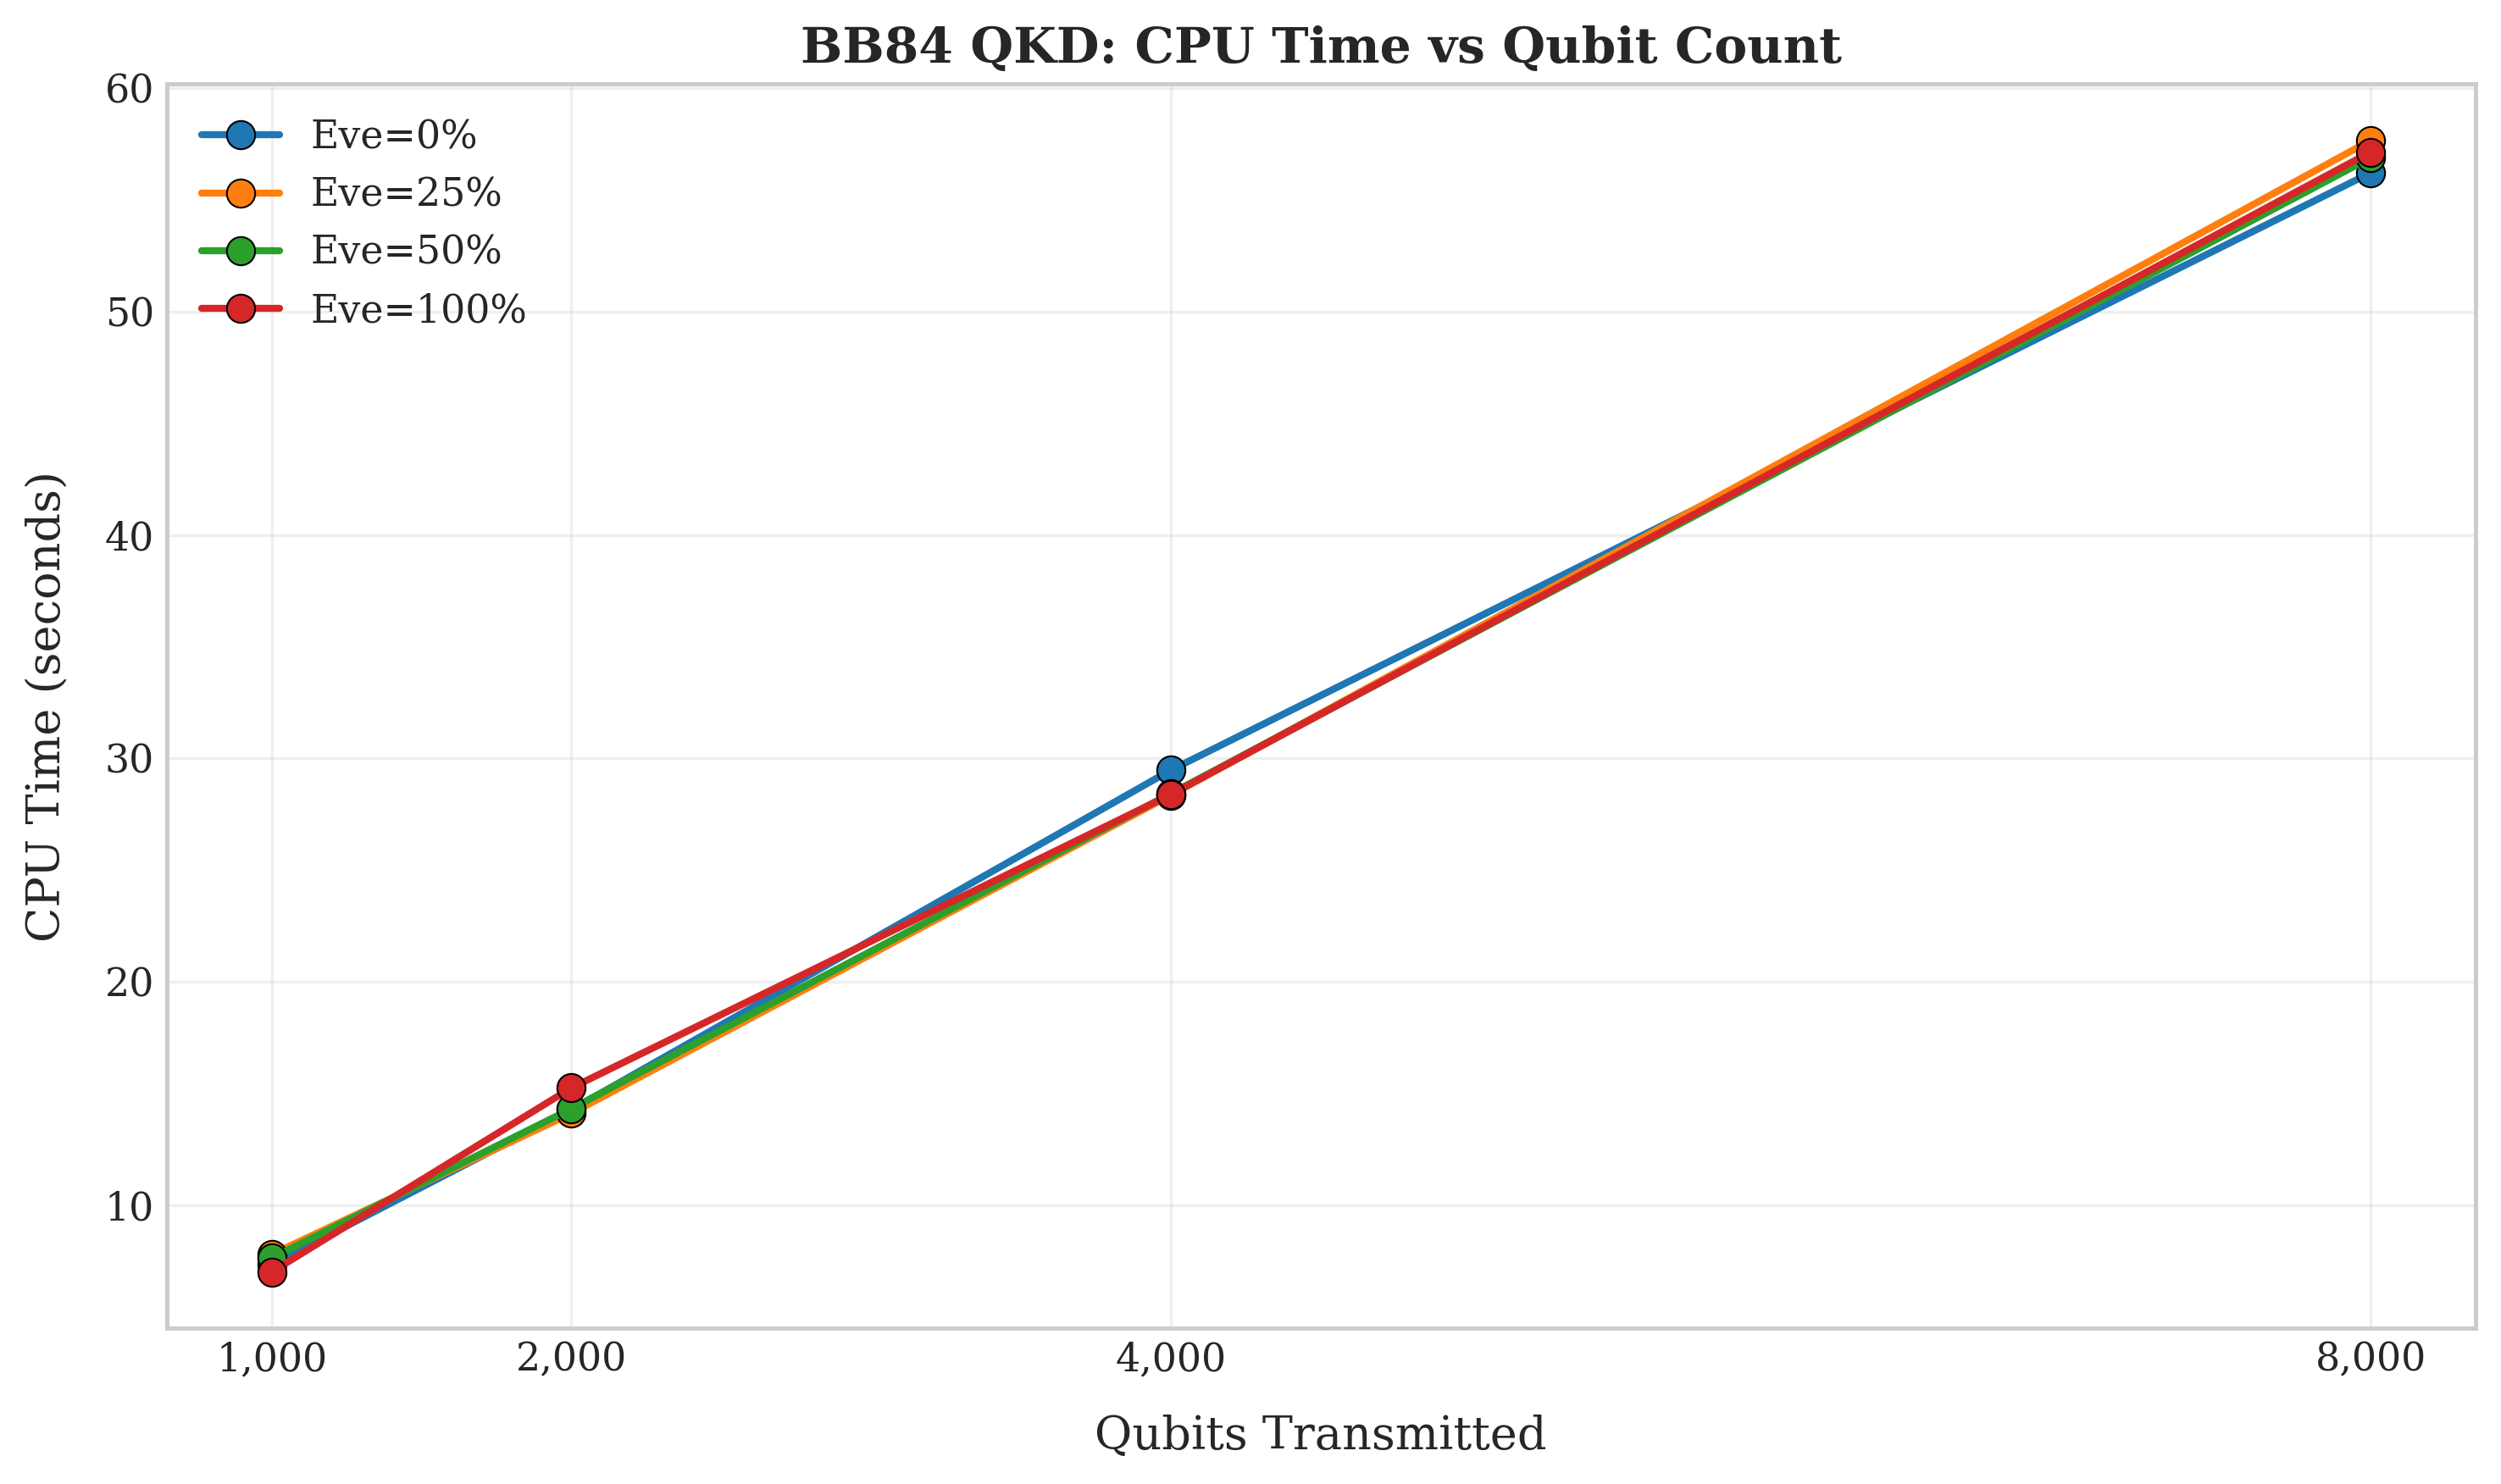

CPU time plot saved!


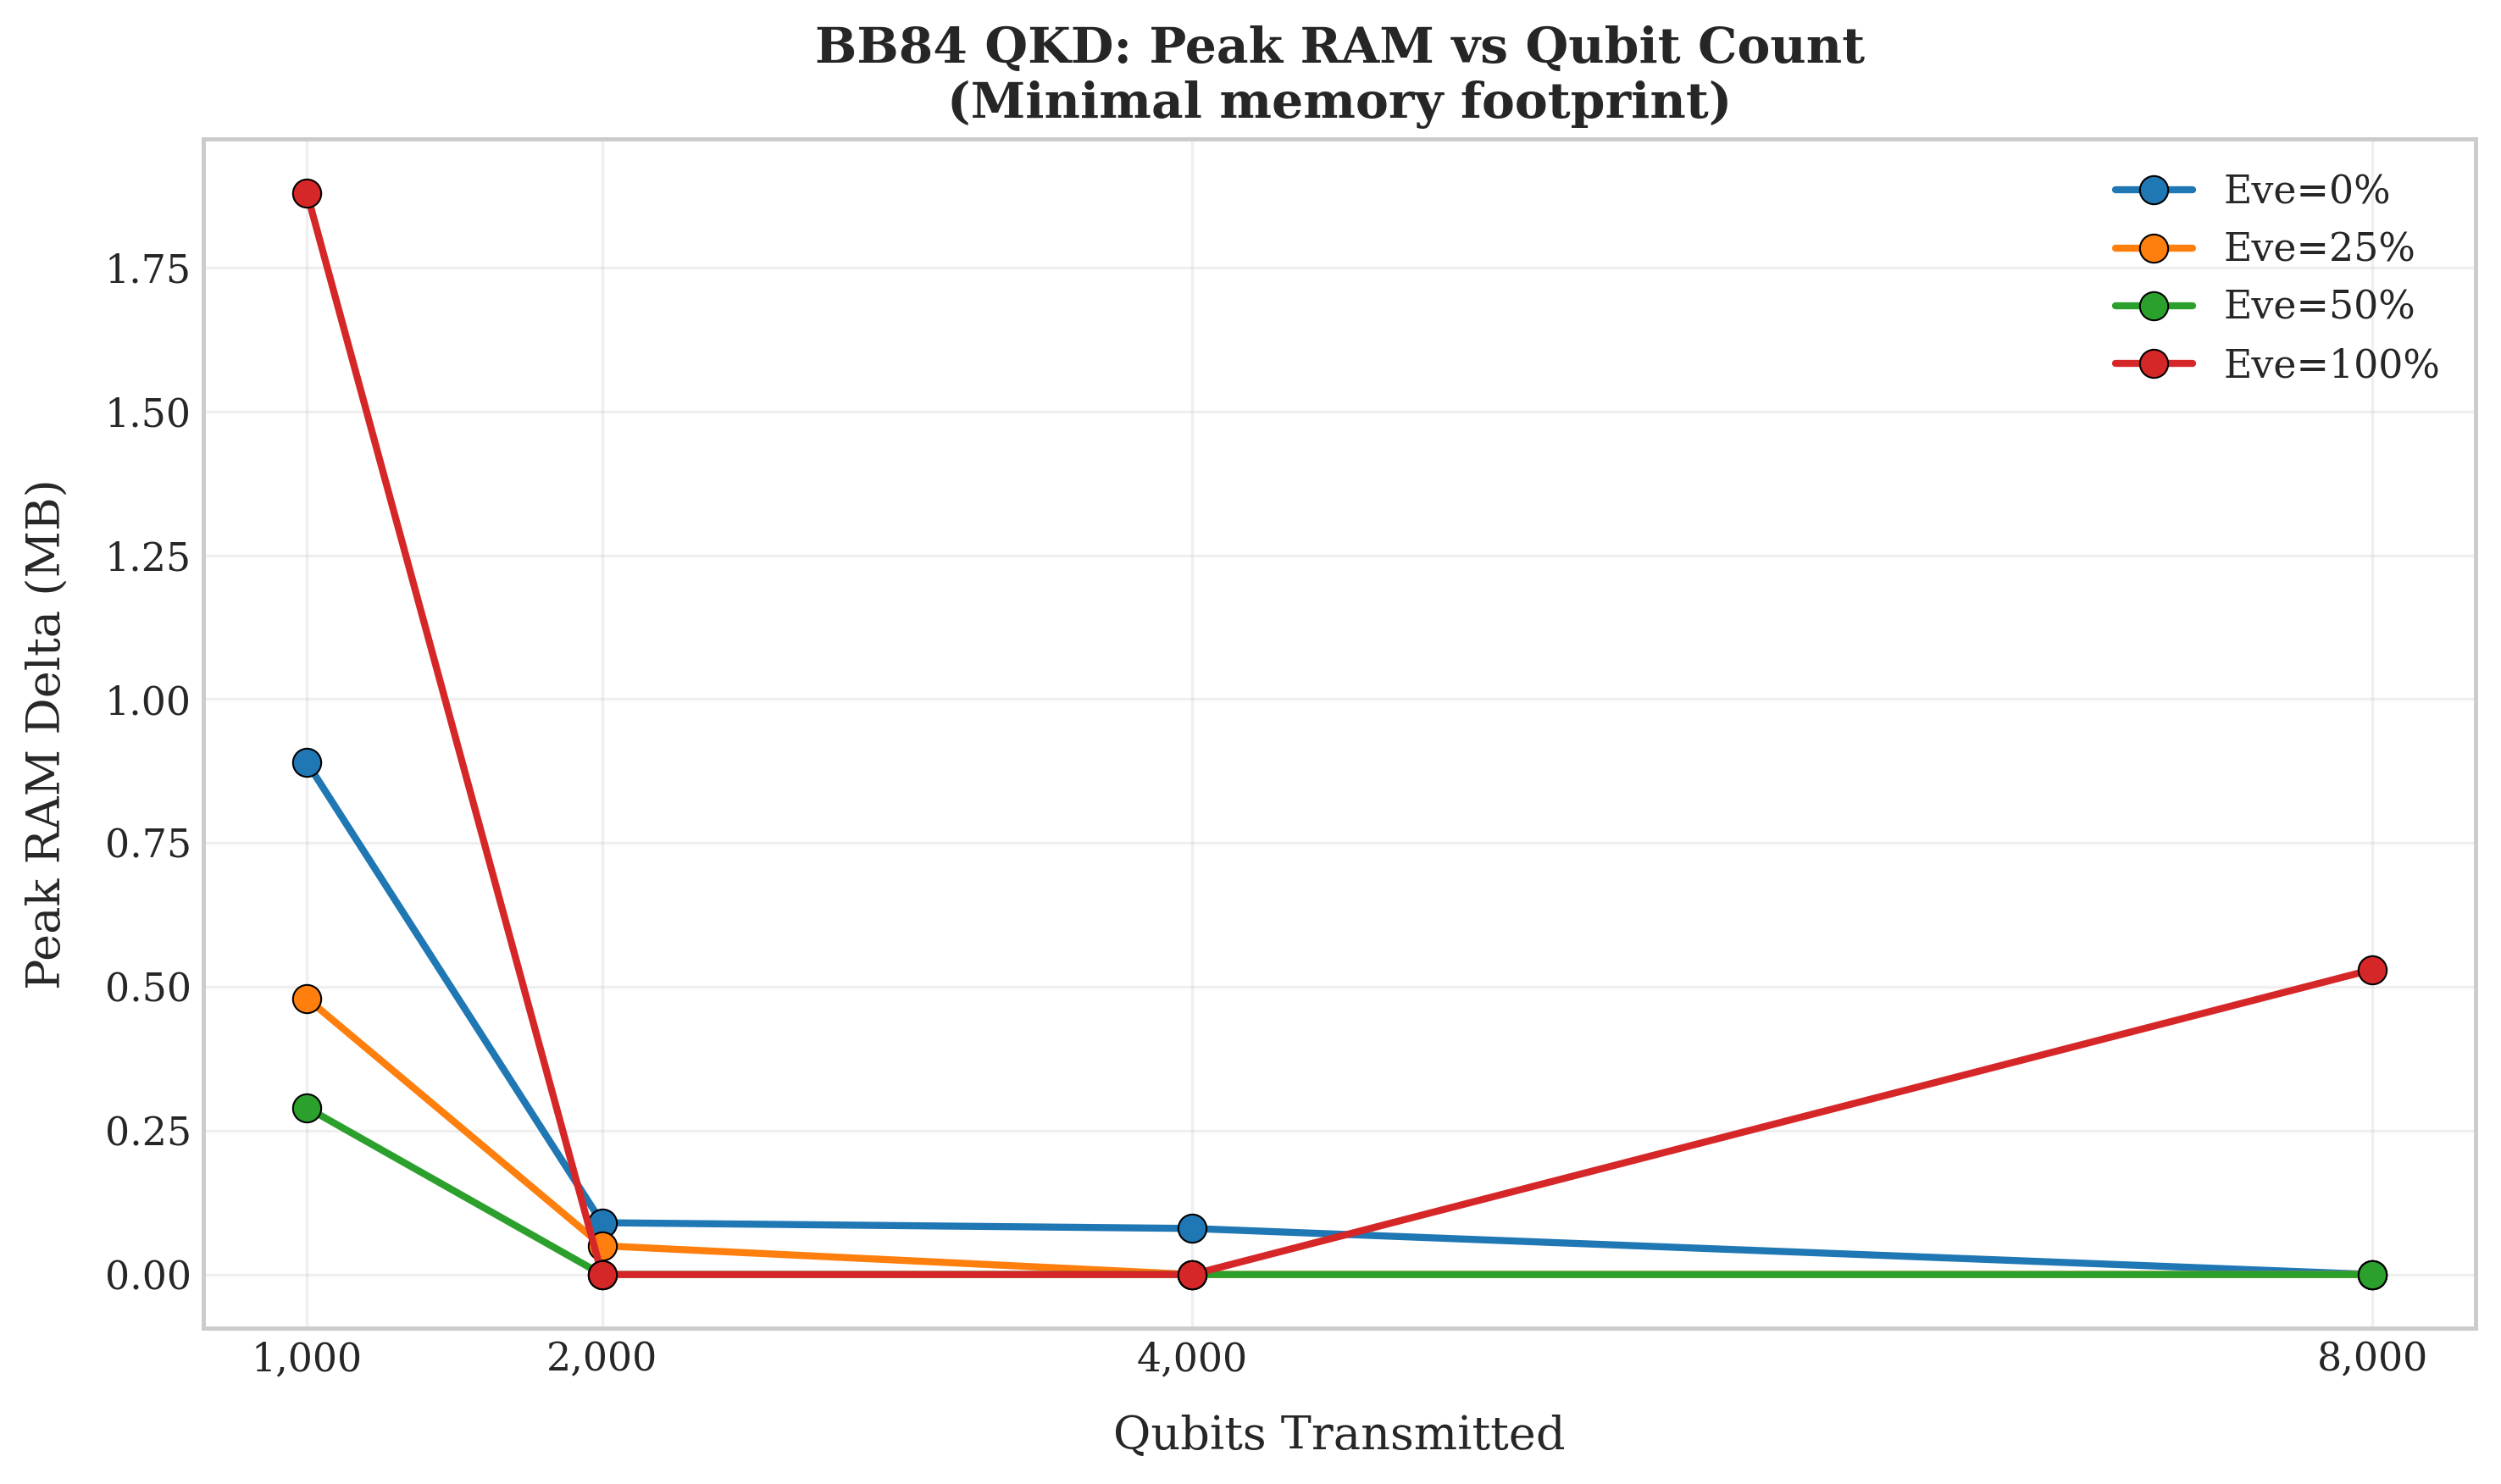

RAM plot saved!


In [18]:
# ── Performance Visualization ─────────────────────────────

# ── Plot 1: Runtime ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
for eve_rate in EAVESDROP_RATES:
    p_data = [r for r in bb84_perf_results if r['eavesdrop_rate'] == eve_rate]
    qubits = [r['n_qubits'] for r in p_data]
    runtimes = [r['runtime_seconds'] for r in p_data]
    ax.plot(qubits, runtimes, 'o-',
            linewidth=2, markersize=8,
            markeredgecolor='black', markeredgewidth=0.5,
            label=f'Eve={eve_rate*100:.0f}%')
ax.set_xlabel('Qubits Transmitted', labelpad=10)
ax.set_ylabel('Runtime (seconds)', labelpad=10)
ax.set_title('BB84 QKD: Runtime vs Qubit Count\n'
             '(Linear scaling — one circuit per qubit)',
             fontweight='bold')
ax.set_xticks(QUBIT_COUNTS)
ax.set_xticklabels([f'{q:,}' for q in QUBIT_COUNTS])
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bb84_performance_runtime.png', dpi=300, bbox_inches='tight')
plt.show()
print("Runtime plot saved!")

# ── Plot 2: Throughput ────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
for eve_rate in EAVESDROP_RATES:
    p_data = [r for r in bb84_perf_results if r['eavesdrop_rate'] == eve_rate]
    qubits = [r['n_qubits'] for r in p_data]
    throughputs = [r['throughput_qps'] for r in p_data]
    ax.plot(qubits, throughputs, 'o-',
            linewidth=2, markersize=8,
            markeredgecolor='black', markeredgewidth=0.5,
            label=f'Eve={eve_rate*100:.0f}%')
ax.set_xlabel('Qubits Transmitted', labelpad=10)
ax.set_ylabel('Throughput (qubits/second)', labelpad=10)
ax.set_title('BB84 QKD: Throughput vs Qubit Count\n'
             '(Stable ~200-230 qubits/second)',
             fontweight='bold')
ax.set_xticks(QUBIT_COUNTS)
ax.set_xticklabels([f'{q:,}' for q in QUBIT_COUNTS])
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bb84_performance_throughput.png', dpi=300, bbox_inches='tight')
plt.show()
print("Throughput plot saved!")

# ── Plot 3: CPU Time ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
for eve_rate in EAVESDROP_RATES:
    p_data = [r for r in bb84_perf_results if r['eavesdrop_rate'] == eve_rate]
    qubits = [r['n_qubits'] for r in p_data]
    cpu_times = [r['cpu_time_seconds'] for r in p_data]
    ax.plot(qubits, cpu_times, 'o-',
            linewidth=2, markersize=8,
            markeredgecolor='black', markeredgewidth=0.5,
            label=f'Eve={eve_rate*100:.0f}%')
ax.set_xlabel('Qubits Transmitted', labelpad=10)
ax.set_ylabel('CPU Time (seconds)', labelpad=10)
ax.set_title('BB84 QKD: CPU Time vs Qubit Count',
             fontweight='bold')
ax.set_xticks(QUBIT_COUNTS)
ax.set_xticklabels([f'{q:,}' for q in QUBIT_COUNTS])
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bb84_performance_cpu.png', dpi=300, bbox_inches='tight')
plt.show()
print("CPU time plot saved!")

# ── Plot 4: Peak RAM ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
for eve_rate in EAVESDROP_RATES:
    p_data = [r for r in bb84_perf_results if r['eavesdrop_rate'] == eve_rate]
    qubits = [r['n_qubits'] for r in p_data]
    ram_values = [r['peak_ram_mb'] for r in p_data]
    ax.plot(qubits, ram_values, 'o-',
            linewidth=2, markersize=8,
            markeredgecolor='black', markeredgewidth=0.5,
            label=f'Eve={eve_rate*100:.0f}%')
ax.set_xlabel('Qubits Transmitted', labelpad=10)
ax.set_ylabel('Peak RAM Delta (MB)', labelpad=10)
ax.set_title('BB84 QKD: Peak RAM vs Qubit Count\n'
             '(Minimal memory footprint)',
             fontweight='bold')
ax.set_xticks(QUBIT_COUNTS)
ax.set_xticklabels([f'{q:,}' for q in QUBIT_COUNTS])
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bb84_performance_ram.png', dpi=300, bbox_inches='tight')
plt.show()
print("RAM plot saved!")

In [20]:
# ── Experiment Log 003: Performance Analysis (Updated) ────
experiment_log_bb84_003 = {
    "experiment_id": "qi26_26_BB84_003",
    "benchmark_type": "BB84_Performance",
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "simulator": "LocalSimulator",
    "protocol": {
        "qubit_counts": [1000, 2000, 4000, 8000],
        "eavesdrop_rates": [0.0, 0.25, 0.50, 1.0],
        "attack_type": "intercept-resend"
    },
    "metrics": {
        "performance": bb84_perf_results
    },
    "environment": {
        "braket_sdk_version": "1.121.0",
        "python_version": "3.12",
        "region": "us-east-1"
    },
    "notes": "Runtime scales linearly with qubit count (~7-8s for 1k to ~57s for 8k). Throughput stable at ~120-140 qubits/second. CPU time closely matches wall clock time. Peak RAM delta minimal (0.00-1.88 MB). Eavesdropping does not significantly affect runtime."
}

with open('bb84_experiment_003.json', 'w') as f:
    json.dump(experiment_log_bb84_003, f, indent=2)

print("Experiment 003 updated!")

Experiment 003 updated!


In [21]:
from google.colab import files

In [22]:
# ── JSON Experiment Logs ──────────────────────────────────
files.download('bb84_experiment_001.json')
files.download('bb84_experiment_002.json')
files.download('bb84_experiment_003.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
# ── Benchmark Plots ───────────────────────────────────────
files.download('bb84_qber_vs_eavesdrop.png')
files.download('bb84_sifted_key.png')
files.download('bb84_security_heatmap.png')
files.download('bb84_secure_key_rate.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
# ── Layer 2 Validation Plots ──────────────────────────────
files.download('bb84_layer2_fidelity.png')
files.download('bb84_layer2_cv.png')
files.download('bb84_layer2_noise.png')
files.download('bb84_layer2_depth.png')
files.download('bb84_runtime.png')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
# ── Performance Plots ─────────────────────────────────────
files.download('bb84_performance_runtime.png')
files.download('bb84_performance_throughput.png')
files.download('bb84_performance_cpu.png')
files.download('bb84_performance_ram.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>